In [97]:
# ============================================================
# InterDIA — (Uncertainty + AD + Conformal)
# ============================================================

In [98]:
# --- Config (edit these paths) ---
DRIVE_ROOT = "data"
TRAIN_CSV  = f"{DRIVE_ROOT}/DIA_trainingset_RDKit_descriptors.csv"
TEST_CSV   = f"{DRIVE_ROOT}/DIA_testset_RDKit_descriptors.csv"
FOLDS_CSV  = f"{DRIVE_ROOT}/DIA_train_with_scaffolds_5fold.csv"
OPTUNA_DB  = f"{DRIVE_ROOT}/optuna-dbs/InterDIA_ML_optuna.db"
OPTUNA_DB_EEC  = f"{DRIVE_ROOT}/optuna-dbs/InterDIA_ML_optuna_eec.db"
OPTUNA_DB_XGB  = f"{DRIVE_ROOT}/optuna-dbs/InterDIA_ML_optuna_xgb.db"
OPTUNA_DB_GB  = f"{DRIVE_ROOT}/optuna-dbs/InterDIA_ML_optuna_gb.db"
OPTUNA_DB_LGB  = f"{DRIVE_ROOT}/optuna-dbs/InterDIA_ML_optuna_lgb.db"
OUTDIR     = f"{DRIVE_ROOT}/exp_artifacts"

In [99]:
# # Google Colab connect
# import os
# from google.colab import drive

# # Check if drive is already mounted
# if not os.path.ismount("/content/drive"):
#     drive.mount('/content/drive')
# else:
#     print("Drive already mounted, skipping...")

In [100]:
# --- Imports & setup ---
import os, json, math, datetime, random, numpy as np, pandas as pd
from pathlib import Path
os.makedirs(OUTDIR, exist_ok=True)

# For RDKit (fingerprints) on Colab
try:
    from rdkit import Chem
    from rdkit.Chem.Scaffolds import MurckoScaffold
    from rdkit.Chem import AllChem, DataStructs
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "rdkit", "-q"])
    from rdkit import Chem
    from rdkit.Chem.Scaffolds import MurckoScaffold
    from rdkit.Chem import AllChem, DataStructs

# XGBoost
try:
    from xgboost import XGBClassifier, DMatrix
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost>=1.7.6", "-q"])
    from xgboost import XGBClassifier, DMatrix

# LightGBM
try:
    from lightgbm import LGBMClassifier
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm", "-q"])
    import lightgbm as lgb

# hyperparameter optimization
try:
    import optuna
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna

# import sys, subprocess
# subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "scikit-learn"])

# Sklearn metrics
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier as GBC
)
from sklearn.pipeline import Pipeline

import joblib

# imbalanced-learn
try:
    from imblearn.ensemble import (
        BalancedRandomForestClassifier,
        EasyEnsembleClassifier,
        BalancedBaggingClassifier
    )
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imblearn", "-q"])

# XGBoost
try:
    from xgboost import XGBClassifier as XGBC
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost>=1.7.6", "-q"])

# Matplotlib for plots
import matplotlib.pyplot as plt

In [101]:
# --- Utility funcs ---
def murcko_scaffold(smi: str) -> str:
    """Return Murcko scaffold SMILES or 'NA' if invalid."""

    mol = Chem.MolFromSmiles(smi or "")
    if mol is None: return "NA"
    core = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(core, isomericSmiles=False) if core is not None else "NA"

def ece_score(y_true, y_prob, n_bins=10):
    """Compute Expected Calibration Error (ECE)."""

    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    bins = np.linspace(0,1,n_bins+1); idx = np.digitize(y_prob, bins)-1
    ece = 0.0; N = len(y_true)
    for b in range(n_bins):
        m = idx==b
        if np.any(m):
            conf = y_prob[m].mean()
            acc  = y_true[m].mean()
            ece += (m.sum()/N) * abs(acc - conf)
    return float(ece)

def morgan_fp_bits(smiles, nBits=2048, radius=2):
    """Return numpy uint8 bit vector (0/1) for a SMILES; zeros if invalid."""

    mol = Chem.MolFromSmiles(smiles or "")
    arr = np.zeros((nBits,), dtype=np.uint8)
    if mol is None: return arr
    bv = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    DataStructs.ConvertToNumpyArray(bv, arr)
    return arr

def ensure_folds(train_df: pd.DataFrame, folds_csv: str) -> pd.DataFrame:
    """Ensure 5-fold split by scaffold; load from folds_csv if possible."""

    need = False
    if os.path.exists(folds_csv):
        f = pd.read_csv(folds_csv)
        merged = train_df[["SMILES","Label"]].merge(f, on=["SMILES","Label"], how="left")
        if merged["fold"].isna().any():
            need = True
        else:
            out = train_df.copy()
            out["fold"] = merged["fold"].astype(int).values
            return out

    # Build SGKF over Murcko
    out = train_df.copy()
    out["scaffold"] = out["SMILES"].apply(murcko_scaffold)
    y = out["Label"].astype(int).values
    groups = out["scaffold"].astype(str).values
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    fold_assign = np.empty(len(out), dtype=int)

    for k, (_, va_idx) in enumerate(sgkf.split(np.zeros(len(y)), y=y, groups=groups)):
        fold_assign[va_idx] = k

    out["fold"] = fold_assign
    out[["SMILES","Label","fold"]].to_csv(folds_csv, index=False)
    return out

# Optional: quick mechanistic flags (keep False to use your existing descriptors only)
ADD_MECH_FLAGS = False
MECH_SMARTS = {
    "has_azo": "N=N",
    "has_aminophenyl": "Nc1ccccc1",
    "has_catechol_like": "c1ccc(c(c1)O)O",
    "has_isothiocyanate": "N=C=S",
    "has_thiourea": "NC(=S)N",
}
SMARTS_PATTERNS = {k: Chem.MolFromSmarts(v) for k,v in MECH_SMARTS.items()}

def add_mechanistic_flags(df: pd.DataFrame) -> pd.DataFrame:
    """Add mechanistic flags to dataframe based on SMARTS patterns."""

    xx = df.copy()
    mols = [Chem.MolFromSmiles(s) for s in xx["SMILES"].astype(str)]
    for name, patt in SMARTS_PATTERNS.items():
        vals = []
        for m in mols:
            if m is None: vals.append(0); continue
            try:
                vals.append(1 if m.HasSubstructMatch(patt) else 0)
            except Exception:
                vals.append(0)
        xx[name] = vals
    for f in ["targets_PD1","targets_PDL1","targets_CTLA4","targets_TNFa","binds_HLA"]:
        xx[f] = 0
    return xx

In [102]:
# --- Load data ---
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
assert {"SMILES","Label"}.issubset(train_df.columns) and {"SMILES","Label"}.issubset(test_df.columns)

# Optional mechanistic augmentation
if ADD_MECH_FLAGS:
    train_df = add_mechanistic_flags(train_df)
    test_df  = add_mechanistic_flags(test_df)

# Ensure folds (SGKF Murcko)
train_df = ensure_folds(train_df, FOLDS_CSV)

In [103]:
# --- Feature matrix alignment ---
exclude = {"SMILES","Label","fold","scaffold"}
feature_cols = [c for c in train_df.columns if c not in exclude and c in test_df.columns]
X = train_df[feature_cols].values
y = train_df["Label"].astype(int).values
X_test = test_df[feature_cols].values
y_test = test_df["Label"].astype(int).values

X.shape, y.shape, X_test.shape, y_test.shape

((477, 196), (477,), (120, 196), (120,))

In [104]:
# Feature preprocessing pipeline
def preprocess_features(X_train, X_test):
    """
    Preprocess features: standardization, variance threshold, correlation filtering

    Args:
        X_train (pd.DataFrame): Training features
        X_test (pd.DataFrame): Test features

    Returns:
        X_train_processed, X_test_processed (pd.DataFrame)
    """
    # 1. Check missing values
    print("\nMissing values:")
    print("Training set:", X_train.isnull().sum().sum())
    print("Test set:", X_test.isnull().sum().sum())

    # 2. Standardization
    scaler = StandardScaler()
    X_train_std = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    X_test_std = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )
    joblib.dump(scaler, 'scaler.pkl')  # Save the scaler for reproducibility

    # 3. Remove zero-variance features
    selector = VarianceThreshold()
    selector.fit(X_train_std)
    keep_vars = X_train.columns[selector.variances_ != 0].tolist()

    X_train_var = X_train_std[keep_vars]
    X_test_var = X_test_std[keep_vars]

    # 4. Remove highly correlated features
    corr_matrix = X_train_var.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    drop_features = [column for column in upper.columns if any(upper[column] > 0.9)]

    X_train_processed = X_train_var.drop(columns=drop_features).reset_index(drop=True)
    X_test_processed = X_test_var.drop(columns=drop_features).reset_index(drop=True)

    print(f"\nFeatures reduced from {X_train.shape[1]} to {X_train_processed.shape[1]}")

    # Save processed features
    X_train_processed.to_csv("X_train_processed2.csv", index=False)
    X_test_processed.to_csv("X_test_processed2.csv", index=False)


    return X_train_processed, X_test_processed

In [105]:
X_train_processed, X_test_processed = preprocess_features(pd.DataFrame(X), pd.DataFrame(X_test))

X_train_processed.shape, X_test_processed.shape


Missing values:
Training set: 0
Test set: 0

Features reduced from 196 to 140


((477, 140), (120, 140))

In [106]:
X_train_processed.head()

,0,1,2,14,15,16,17,18,19,20,...,185,186,187,188,189,190,191,193,194,195
0,-0.452875,1.344465,0.551264,-0.525136,-0.384981,-0.181361,1.395076,0.554831,-0.812459,0.507059,...,-0.146333,-0.22267,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384
1,0.310322,-0.632257,-0.887194,-0.263887,-0.305248,-0.181361,-1.140124,-0.755872,-0.247407,-0.915263,...,-0.146333,-0.22267,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,5.551415,-0.238492,5.974304
2,1.983159,-1.644450,-1.567194,-0.530553,-0.315105,-0.181361,-0.672837,-0.799998,-1.087602,-0.915263,...,6.833740,-0.22267,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384
3,-0.093806,0.800838,0.511898,0.283293,0.611727,-0.181361,0.164995,-1.141063,0.469142,-0.061968,...,-0.146333,-0.22267,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384
4,1.049581,-0.480968,-0.483586,0.474686,0.471975,-0.181361,-0.734095,-1.141063,0.663707,-0.488440,...,-0.146333,-0.22267,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384


In [107]:
X_test_processed.head()

,0,1,2,14,15,16,17,18,19,20,...,185,186,187,188,189,190,191,193,194,195
0,-0.927408,0.011660,0.460791,-0.257990,0.213746,-0.181361,-0.704323,2.048809,-0.101188,2.186080,...,-0.146333,-0.222670,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384
1,-0.944306,0.331971,0.415761,-0.278435,0.004021,-0.181361,-0.668410,0.287486,1.979562,0.765235,...,-0.146333,-0.222670,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384
2,-1.838457,1.707719,2.908821,3.180967,2.176713,-0.181361,3.222955,0.286193,1.388567,-0.915263,...,-0.146333,-0.222670,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384
3,0.370871,-0.298892,-0.594226,-0.533262,-0.345554,-0.181361,-0.268807,0.561449,-1.087602,-0.915263,...,-0.146333,-0.222670,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384
4,-1.158339,3.539286,2.738372,1.265508,1.149556,-0.181361,1.890135,4.199888,-0.150433,1.398894,...,-0.146333,3.862468,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384


In [108]:
# #Genetic Algorithm Feature Selection (GA)

# import numpy as np
# try:
#   from deap import base, creator, tools, algorithms
# except Exception:
#   import sys, subprocess
#   subprocess.check_call([sys.executable, "-m", "pip", "install", "deap", "-q"])
#   from deap import base, creator, tools, algorithms
# from sklearn.metrics import matthews_corrcoef, make_scorer
# from imblearn.ensemble import BalancedRandomForestClassifier
# from sklearn.model_selection import cross_val_score
# import random

# RANDOM_SEED = 42
# np.random.seed(RANDOM_SEED)
# random.seed(RANDOM_SEED)

# # Replace with your actual data
# X_train_df = X_train_processed  # Your training feature DataFrame
# y_train_df = pd.DataFrame(y)  # Your training label Series

# # Save feature names
# feature_names = X_train_df.columns

# # Convert to numpy arrays
# X_train = X_train_df.values
# y_train = y_train_df.values

# # Define evaluation function
# def evaluate(individual):
#    selected_features = [index for index, value in enumerate(individual) if value == 1]
#    if not selected_features:
#        return -1,  # Return -1 score if no features selected (worst case)
#    X_train_selected = X_train[:, selected_features]
#    clf = BalancedRandomForestClassifier(
#        n_estimators=255,
#        criterion="gini",
#        max_depth=16,
#        max_features=30,
#        bootstrap=True,
#        sampling_strategy='auto',
#        replacement=False,
#        random_state=1,
#        verbose=False,
#        n_jobs=-1
#    )
#    mcc_scorer = make_scorer(matthews_corrcoef)
#    scores = cross_val_score(clf, X_train_selected, y_train, cv=5, scoring=mcc_scorer)
#    return scores.mean(),

# # Set GA parameters
# NUM_GENES = X_train.shape[1]  # Number of genes equals number of features
# # POP_SIZE = 50  # Population size
# POP_SIZE = 20  # Population size
# NGEN = 10     # Number of generations
# NGEN = 40     # Number of generations
# CXPB = 0.5    # Crossover probability
# MUTPB = 0.2   # Mutation probability

# # Define genetic algorithm type
# creator.create("FitnessMax", base.Fitness, weights=(1.0,))
# creator.create("Individual", list, fitness=creator.FitnessMax)

# toolbox = base.Toolbox()
# toolbox.register("attr_bool", np.random.randint, 2)
# toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=NUM_GENES)
# toolbox.register("population", tools.initRepeat, list, toolbox.individual)
# toolbox.register("evaluate", evaluate)
# toolbox.register("mate", tools.cxTwoPoint)
# toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
# toolbox.register("select", tools.selTournament, tournsize=3)

# # Elite preservation strategy
# hof = tools.HallOfFame(1)

# # Generate initial population
# population = toolbox.population(n=POP_SIZE)

# # Run genetic algorithm
# result_population, logbook = algorithms.eaSimple(population, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN,
#                                               stats=None, halloffame=hof, verbose=True)

# # Get best individual
# best_individual = hof[0]
# selected_features = [index for index, value in enumerate(best_individual) if value == 1]

# # Print selected feature names
# selected_feature_names = feature_names[selected_features]
# print(f"Selected features: {selected_feature_names}")
# print(f"Best individual MCC on training set: {evaluate(best_individual)[0]}")

# # Train and evaluate model with selected features
# X_train_selected = X_train[:, selected_features]

**Number of Trials**

In [109]:
n_trials = 1
n_trials_eec = 1
n_trials_xgb = 1
n_trials_gb = 1
n_trials_lgb = 1

**Balanced Random Forest Classifier**

In [110]:
# # Balanced Random Forest Classifier

# def objective(trial):
#     """Objective function for hyperparameter tuning using Optuna for Balanced Random Forest Classifier."""

#     # Define hyperparameters to tune
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 40, 300),
#         'max_depth': trial.suggest_int('max_depth', 1, 25),
#         # 'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
#         # 'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
#         'sampling_strategy': trial.suggest_categorical('sampling_strategy', ['auto', 'not minority', 'not majority']),
#         'replacement': trial.suggest_categorical('replacement', [True, False]),
#         'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
#         'class_weight': 'balanced',  # This handles class imbalance
#         'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
#         'random_state': 42
#     }

#     # Stratified Group K-Fold Cross-Validation
#     # Reuse the existing folds from train_df to ensure consistency
#     folds = train_df["fold"].values
#     sgkf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # Shuffle=False because folds are already assigned

#     oof_preds = np.zeros(len(X_train_processed)) # Out-of-fold predictions
#     for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_train_processed, y)):
#         # Only use folds other than the calibration fold for hyperparameter tuning
#         if fold == 0:
#             continue

#         X_train_fold, X_val_fold = X_train_processed.iloc[train_idx], X_train_processed.iloc[val_idx]
#         y_train_fold, y_val_fold = y[train_idx], y[val_idx]

#         model = BalancedRandomForestClassifier(
#             **params,
#             n_jobs=-1
#         )
#         model.fit(X_train_fold, y_train_fold)
#         oof_preds[val_idx] = model.predict_proba(X_val_fold)[:, 1]

#     # Evaluate the model on the out-of-fold predictions
#     # Exclude predictions from the calibration fold (fold 0)
#     non_calib_mask = (folds != 0)
#     auroc = roc_auc_score(y[non_calib_mask], oof_preds[non_calib_mask])

#     return auroc

In [111]:
# # Create an Optuna study to optimize the objective
# study = optuna.create_study(
#     direction='maximize',
#     study_name='InterDIA_ML_optuna',
#     storage='sqlite:///'+OPTUNA_DB,
#     load_if_exists=True
# )  # We want to maximize AUROC

# # Start the optimization process (Optuna will try different hyperparameter combinations)
# study.optimize(objective, n_trials=n_trials)  # 50 trials is a good starting point

# # Get the best trial and its parameters
# best_trial = study.best_trial
# print(f"Best trial parameters: {best_trial.params}")
# print(f"Best AUROC: {best_trial.value}")

In [112]:
# # Best hyperparameters found by Optuna
# best_params = best_trial.params

# # Train the final model with the best parameters
# final_model = BalancedRandomForestClassifier(**best_params)
# final_model.fit(X_train_processed, y)

# # Predict on the test set and evaluate
# y_pred = final_model.predict_proba(X_test_processed)[:, 1]
# test_auroc = roc_auc_score(y_test, y_pred)
# test_auprc = average_precision_score(y_test, y_pred)
# test_brier = brier_score_loss(y_test, y_pred)

# print(f"Final Model AUROC: {test_auroc:.4f}")
# print(f"Final Model AUPRC: {test_auprc:.4f}")
# print(f"Final Model Brier Score: {test_brier:.4f}")

# best_params

In [113]:
# # --- Train ensemble (5 seeds) ---
# seeds = [11,23,37,47,59]
# models = []
# for s in seeds:
#     clf = BalancedRandomForestClassifier(
#         **best_params,
#         random_state=s
#     )
#     clf.fit(X_train_processed, y)
#     models.append(clf)

# def ensemble_stats(models, Xm):
#     """Compute mean and variance of ensemble predictions."""
#     P = np.vstack([m.predict_proba(Xm)[:,1] for m in models])
#     return P.mean(axis=0), P.var(axis=0)

# p_cal_mean, p_cal_var = ensemble_stats(models, X_train_processed)
# p_test_mean, p_test_var = ensemble_stats(models, X_test_processed)

**EasyEnsembleClassifier**

In [114]:
# # EasyEnsembleClassifier

# def objective_eec(trial):
#     """Objective function for hyperparameter tuning using Optuna for EasyEnsembleClassifier."""

#     # Define hyperparameters to tune
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 40, 300),
#         'learning_rate': trial.suggest_float('learning_rate', 0.2, 1.0),
#         # 'algorithm': trial.suggest_categorical('algorithm', ['SAMME', 'SAMME.R']),
#         'algorithm': 'SAMME',
#         'base_estimator_max_depth': trial.suggest_int('base_estimator_max_depth', 1, 10),
#     }

#     # Stratified Group K-Fold Cross-Validation
#     # Reuse the existing folds from train_df to ensure consistency
#     folds = train_df["fold"].values
#     sgkf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # Shuffle=False because folds are already assigned

#     oof_preds = np.zeros(len(X_train_processed)) # Out-of-fold predictions
#     for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_train_processed, y)):
#         # Only use folds other than the calibration fold for hyperparameter tuning
#         if fold == 0:
#             continue

#         X_train_fold, X_val_fold = X_train_processed.iloc[train_idx], X_train_processed.iloc[val_idx]
#         y_train_fold, y_val_fold = y[train_idx], y[val_idx]

#         base_estimator = DecisionTreeClassifier(
#             max_depth=params['base_estimator_max_depth'],
#             random_state=42
#         )

#         model = EasyEnsembleClassifier(
#             n_estimators=10,
#             estimator=AdaBoostClassifier(
#                estimator=base_estimator,
#                n_estimators=int(params['n_estimators']),
#                learning_rate=params['learning_rate'],
#                algorithm=params['algorithm'],
#                random_state=42
#             ),
#             random_state=42,
#             n_jobs=-1
#         )
#         model.fit(X_train_fold, y_train_fold)
#         oof_preds[val_idx] = model.predict_proba(X_val_fold)[:, 1]

#     # Evaluate the model on the out-of-fold predictions
#     # Exclude predictions from the calibration fold (fold 0)
#     non_calib_mask = (folds != 0)
#     auroc = roc_auc_score(y[non_calib_mask], oof_preds[non_calib_mask])

#     return auroc

In [115]:
# # Create an Optuna study to optimize the objective
# study_eec = optuna.create_study(
#     direction='maximize',
#     study_name='InterDIA_ML_optuna_eec',
#     storage='sqlite:///'+OPTUNA_DB_EEC,
#     load_if_exists=True
# )  # We want to maximize AUROC

# # Start the optimization process (Optuna will try different hyperparameter combinations)
# study_eec.optimize(objective_eec, n_trials=n_trials_eec)  # 50 trials is a good starting point

# # Get the best trial and its parameters
# best_trial_eec = study_eec.best_trial
# print(f"Best trial parameters: {best_trial_eec.params}")
# print(f"Best AUROC: {best_trial_eec.value}")

In [116]:
# # Best hyperparameters found by Optuna
# best_params_eec = best_trial_eec.params

# # Train the final model with the best parameters
# base_estimator_ecc = DecisionTreeClassifier(
#     max_depth=best_params_eec['base_estimator_max_depth'],
#     random_state=42
# )
# final_model_eec = EasyEnsembleClassifier(
#     n_estimators=10,
#     estimator=AdaBoostClassifier(
#         estimator=base_estimator_ecc,
#         n_estimators=int(best_params_eec['n_estimators']),
#         learning_rate=best_params_eec['learning_rate'],
#         # algorithm=best_params_eec['algorithm'],
#         random_state=42
#     ),
#     random_state=42,
#     n_jobs=-1
# )
# final_model_eec.fit(X_train_processed, y)

# # Predict on the test set and evaluate
# y_pred_eec = final_model_eec.predict_proba(X_test_processed)[:, 1]
# test_auroc_eec = roc_auc_score(y_test, y_pred_eec)
# test_auprc_eec = average_precision_score(y_test, y_pred_eec)
# test_brier_eec = brier_score_loss(y_test, y_pred_eec)

# print(f"Final Model AUROC: {test_auroc_eec:.4f}")
# print(f"Final Model AUPRC: {test_auprc_eec:.4f}")
# print(f"Final Model Brier Score: {test_brier_eec:.4f}")

# best_params_eec

In [117]:
# # --- Train EEC ensemble (5 seeds) ---
# seeds = [11,23,37,47,59]
# models = []
# for s in seeds:
#     base_estimator_ecc = DecisionTreeClassifier(
#         max_depth=best_params_eec['base_estimator_max_depth'],
#         random_state=42
#     )
#     clf = EasyEnsembleClassifier(
#         n_estimators=10,
#         estimator=AdaBoostClassifier(
#             estimator=base_estimator_ecc,
#             n_estimators=int(best_params_eec['n_estimators']),
#             learning_rate=best_params_eec['learning_rate'],
#             # algorithm=best_params_eec['algorithm'],
#             random_state=42
#         ),
#         random_state=s,
#         n_jobs=-1
#     )
#     clf.fit(X_train_processed, y)
#     models.append(clf)

# def ensemble_stats(models, Xm):
#     """Compute mean and variance of ensemble predictions."""
#     P = np.vstack([m.predict_proba(Xm)[:,1] for m in models])
#     return P.mean(axis=0), P.var(axis=0)

# p_cal_mean_eec, p_cal_var_eec = ensemble_stats(models, X_train_processed)
# p_test_mean_eec, p_test_var_eec = ensemble_stats(models, X_test_processed)

In [118]:
# p_cal_mean = p_cal_mean_eec; p_cal_var = p_cal_var_eec
# p_test_mean = p_test_mean_eec; p_test_var = p_test_var_eec

**XGBoost with BalancedBagging**

In [119]:
# # XGBoost with BalancedBagging

# def objective_xgb(trial):
#     """Objective function for hyperparameter tuning using Optuna for EasyEnsembleClassifier."""

#     # Calculate scale_pos_weight
#     n_positive = np.sum(y == 1)
#     n_negative = np.sum(y == 0)
#     scale_pos_weight = n_negative / n_positive

#     # Define hyperparameters to tune
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 20, 300, step=1),
#         'learning_rate': trial.suggest_float('learning_rate', 0.1, 1.0, step=0.1),
#         'booster': trial.suggest_categorical('booster', [0, 1, 2]),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0, step=0.1),
#         'colsample_bynode': trial.suggest_float('colsample_bynode', 0.3, 1.0, step=0.1),
#         'gamma': trial.suggest_float('gamma', 1e-5, 1, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 1, log=True),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10, step=1),
#         'max_depth': trial.suggest_int('max_depth', 1, 10),
#         'subsample': trial.suggest_float('subsample', 0.3, 1.0, step=0.1),
#     }

#     # Stratified Group K-Fold Cross-Validation
#     # Reuse the existing folds from train_df to ensure consistency
#     folds = train_df["fold"].values
#     sgkf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # Shuffle=False because folds are already assigned

#     oof_preds = np.zeros(len(X_train_processed)) # Out-of-fold predictions
#     for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_train_processed, y)):
#         # Only use folds other than the calibration fold for hyperparameter tuning
#         if fold == 0:
#             continue

#         X_train_fold, X_val_fold = X_train_processed.iloc[train_idx], X_train_processed.iloc[val_idx]
#         y_train_fold, y_val_fold = y[train_idx], y[val_idx]

#         booster = ["gbtree", "gblinear", "dart"][params["booster"]]

#         base_estimator = XGBC(
#            n_estimators=int(params["n_estimators"]),
#            learning_rate=params["learning_rate"],
#            booster=booster,
#            colsample_bytree=params["colsample_bytree"],
#            colsample_bynode=params["colsample_bynode"],
#            gamma=params["gamma"],
#            reg_lambda=params["reg_lambda"],
#            min_child_weight=int(params["min_child_weight"]),
#            max_depth=int(params["max_depth"]),
#            subsample=params["subsample"],
#            scale_pos_weight=scale_pos_weight,
#            random_state=42,
#            verbosity=0,
#            n_jobs=-1
#        )

#         model = BalancedBaggingClassifier(
#             estimator=base_estimator,
#             n_estimators=10,
#             random_state=42,
#             n_jobs=-1
#         )
#         model.fit(X_train_fold, y_train_fold)
#         oof_preds[val_idx] = model.predict_proba(X_val_fold)[:, 1]

#     # Evaluate the model on the out-of-fold predictions
#     # Exclude predictions from the calibration fold (fold 0)
#     non_calib_mask = (folds != 0)
#     auroc = roc_auc_score(y[non_calib_mask], oof_preds[non_calib_mask])

#     return auroc

In [120]:
# # Create an Optuna study to optimize the objective
# study_xgb = optuna.create_study(
#     direction='maximize',
#     study_name='InterDIA_ML_optuna_xgb',
#     storage='sqlite:///'+OPTUNA_DB_XGB,
#     load_if_exists=True
# )  # We want to maximize AUROC

# # Start the optimization process (Optuna will try different hyperparameter combinations)
# study_xgb.optimize(objective_xgb, n_trials=n_trials_xgb)  # 50 trials is a good starting point

# # Get the best trial and its parameters
# best_trial_xgb = study_xgb.best_trial
# print(f"Best trial parameters: {best_trial_xgb.params}")
# print(f"Best AUROC: {best_trial_xgb.value}")

In [121]:
# # Best hyperparameters found by Optuna
# best_params_xgb = best_trial_xgb.params

# # Train the final model with the best parameters
# # Calculate scale_pos_weight
# n_positive = np.sum(y == 1)
# n_negative = np.sum(y == 0)
# scale_pos_weight = n_negative / n_positive

# booster = ["gbtree", "gblinear", "dart"][best_params_xgb["booster"]]

# base_model = XGBC(
#         n_estimators=int(best_params_xgb["n_estimators"]),
#         learning_rate=best_params_xgb["learning_rate"],
#         booster=booster,
#         colsample_bytree=best_params_xgb["colsample_bytree"],
#         colsample_bynode=best_params_xgb["colsample_bynode"],
#         gamma=best_params_xgb["gamma"],
#         reg_lambda=best_params_xgb["reg_lambda"],
#         min_child_weight=int(best_params_xgb["min_child_weight"]),
#         max_depth=int(best_params_xgb["max_depth"]),
#         subsample=best_params_xgb["subsample"],
#         scale_pos_weight=scale_pos_weight,
#         random_state=42,
#         verbosity=0,
#         n_jobs=-1
#     )

# final_model_xgb = BalancedBaggingClassifier(
#     estimator=base_model,
#     n_estimators=10,
#     random_state=42,
#     n_jobs=-1
# )
# final_model_xgb.fit(X_train_processed, y)

# # Predict on the test set and evaluate
# y_pred_xgb = final_model_xgb.predict_proba(X_test_processed)[:, 1]
# test_auroc_xgb = roc_auc_score(y_test, y_pred_xgb)
# test_auprc_xgb = average_precision_score(y_test, y_pred_xgb)
# test_brier_xgb = brier_score_loss(y_test, y_pred_xgb)

# print(f"Final Model AUROC: {test_auroc_xgb:.4f}")
# print(f"Final Model AUPRC: {test_auprc_xgb:.4f}")
# print(f"Final Model Brier Score: {test_brier_xgb:.4f}")

# best_params_xgb

In [122]:
# # --- Train XGB ensemble (5 seeds) ---
# seeds = [11,23,37,47,59]
# models_xgb = []
# for s in seeds:
#     base_model = XGBC(
#         n_estimators=int(best_params_xgb["n_estimators"]),
#         learning_rate=best_params_xgb["learning_rate"],
#         booster=booster,
#         colsample_bytree=best_params_xgb["colsample_bytree"],
#         colsample_bynode=best_params_xgb["colsample_bynode"],
#         gamma=best_params_xgb["gamma"],
#         reg_lambda=best_params_xgb["reg_lambda"],
#         min_child_weight=int(best_params_xgb["min_child_weight"]),
#         max_depth=int(best_params_xgb["max_depth"]),
#         subsample=best_params_xgb["subsample"],
#         scale_pos_weight=scale_pos_weight,
#         random_state=42,
#         verbosity=0,
#         n_jobs=-1
#     )
#     clf = BalancedBaggingClassifier(
#         estimator=base_model,
#         n_estimators=10,
#         random_state=s,
#         n_jobs=-1
#     )
#     clf.fit(X_train_processed, y)
#     models_xgb.append(clf)

# def ensemble_stats(models, Xm):
#     """Compute mean and variance of ensemble predictions."""
#     P = np.vstack([m.predict_proba(Xm)[:,1] for m in models])
#     return P.mean(axis=0), P.var(axis=0)

# p_cal_mean_xgb, p_cal_var_xgb = ensemble_stats(models_xgb, X_train_processed)
# p_test_mean_xgb, p_test_var_xgb = ensemble_stats(models_xgb, X_test_processed)

In [123]:
# p_cal_mean = p_cal_mean_xgb; p_cal_var = p_cal_var_xgb
# p_test_mean = p_test_mean_xgb; p_test_var = p_test_var_xgb

**Gradient Boosting with BalancedBagging**

In [124]:
# # Gradient Boosting with BalancedBagging

# def objective_gb(trial):
#     """Objective function for hyperparameter tuning using Optuna for EasyEnsembleClassifier."""

#     # Define hyperparameters to tune
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 25, 250, step=1),
#         'learning_rate': trial.suggest_float('learning_rate', 0.1, 1.0, step=0.1),
#         'criterion': trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error']),
#         'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
#         'max_depth': trial.suggest_int('max_depth', 2, 10, step=1),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.1),
#     }

#     # Stratified Group K-Fold Cross-Validation
#     # Reuse the existing folds from train_df to ensure consistency
#     folds = train_df["fold"].values
#     sgkf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # Shuffle=False because folds are already assigned

#     oof_preds = np.zeros(len(X_train_processed)) # Out-of-fold predictions
#     for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_train_processed, y)):
#         # Only use folds other than the calibration fold for hyperparameter tuning
#         if fold == 0:
#             continue

#         X_train_fold, X_val_fold = X_train_processed.iloc[train_idx], X_train_processed.iloc[val_idx]
#         y_train_fold, y_val_fold = y[train_idx], y[val_idx]

#         base_estimator = GBC(
#             n_estimators=int(params["n_estimators"]),
#             learning_rate=params["learning_rate"],
#             criterion=params["criterion"],
#             max_depth=int(params["max_depth"]),
#             max_features=params["max_features"],
#             subsample=params["subsample"],
#             random_state=42,
#             verbose=False
#         )

#         model = BalancedBaggingClassifier(
#             estimator=base_estimator,
#             n_estimators=10,
#             random_state=42,
#             n_jobs=-1
#         )
#         model.fit(X_train_fold, y_train_fold)
#         oof_preds[val_idx] = model.predict_proba(X_val_fold)[:, 1]

#     # Evaluate the model on the out-of-fold predictions
#     # Exclude predictions from the calibration fold (fold 0)
#     non_calib_mask = (folds != 0)
#     auroc = roc_auc_score(y[non_calib_mask], oof_preds[non_calib_mask])

#     return auroc

In [125]:
# # Create an Optuna study to optimize the objective
# study_gb = optuna.create_study(
#     direction='maximize',
#     study_name='InterDIA_ML_optuna_gb',
#     storage='sqlite:///'+OPTUNA_DB_GB,
#     load_if_exists=True
# )  # We want to maximize AUROC

# # Start the optimization process (Optuna will try different hyperparameter combinations)
# study_gb.optimize(objective_gb, n_trials=n_trials_gb)  # 50 trials is a good starting point

# # Get the best trial and its parameters
# best_trial_gb = study_gb.best_trial
# print(f"Best trial parameters: {best_trial_gb.params}")
# print(f"Best AUROC: {best_trial_gb.value}")

In [126]:
# # Best hyperparameters found by Optuna
# params = best_trial_gb.params

# # Train the final model with the best parameters
# base_estimator = GBC(
#             n_estimators=int(params["n_estimators"]),
#             learning_rate=params["learning_rate"],
#             criterion=params["criterion"],
#             max_depth=int(params["max_depth"]),
#             max_features=params["max_features"],
#             subsample=params["subsample"],
#             random_state=42,
#             verbose=False
#         )

# final_model_gb = BalancedBaggingClassifier(
#     estimator=base_estimator,
#     n_estimators=10,
#     random_state=42,
#     n_jobs=-1
# )
# final_model_gb.fit(X_train_processed, y)

# # Predict on the test set and evaluate
# y_pred_gb = final_model_gb.predict_proba(X_test_processed)[:, 1]
# test_auroc_gb = roc_auc_score(y_test, y_pred_gb)
# test_auprc_gb = average_precision_score(y_test, y_pred_gb)
# test_brier_gb = brier_score_loss(y_test, y_pred_gb)

# print(f"Final Model AUROC: {test_auroc_gb:.4f}")
# print(f"Final Model AUPRC: {test_auprc_gb:.4f}")
# print(f"Final Model Brier Score: {test_brier_gb:.4f}")

# params

In [127]:
# # --- Train Gradient Boosting ensemble (5 seeds) ---
# seeds = [11,23,37,47,59]
# models_gb = []
# for s in seeds:
#     base_estimator = GBC(
#             n_estimators=int(params["n_estimators"]),
#             learning_rate=params["learning_rate"],
#             criterion=params["criterion"],
#             max_depth=int(params["max_depth"]),
#             max_features=params["max_features"],
#             subsample=params["subsample"],
#             random_state=42,
#             verbose=False
#         )

#     clf = BalancedBaggingClassifier(
#         estimator=base_estimator,
#         n_estimators=10,
#         random_state=42,
#         n_jobs=-1
#     )
#     clf.fit(X_train_processed, y)
#     models_gb.append(clf)

# def ensemble_stats(models, Xm):
#     """Compute mean and variance of ensemble predictions."""
#     P = np.vstack([m.predict_proba(Xm)[:,1] for m in models])
#     return P.mean(axis=0), P.var(axis=0)

# p_cal_mean_gb, p_cal_var_gb = ensemble_stats(models_gb, X_train_processed)
# p_test_mean_gb, p_test_var_gb = ensemble_stats(models_gb, X_test_processed)

In [128]:
# p_cal_mean = p_cal_mean_gb; p_cal_var = p_cal_var_gb
# p_test_mean = p_test_mean_gb; p_test_var = p_test_var_gb

**LightGBM with BalancedBagging**

In [129]:
# Gradient Boosting with BalancedBagging

def objective_lgb(trial):
    """Objective function for hyperparameter tuning using Optuna for EasyEnsembleClassifier."""

    # Define hyperparameters to tune
    params = {
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart']),
        'n_estimators': trial.suggest_int('n_estimators', 40, 300, 1),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, step=0.01),
        'max_depth': trial.suggest_int('max_depth', 2, 30, 1),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0, step=0.01),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.01),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 1, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 1, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 20, 1),
    }

    # Stratified Group K-Fold Cross-Validation
    # Reuse the existing folds from train_df to ensure consistency
    folds = train_df["fold"].values
    sgkf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # Shuffle=False because folds are already assigned

    oof_preds = np.zeros(len(X_train_processed)) # Out-of-fold predictions
    for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_train_processed, y)):
        # Only use folds other than the calibration fold for hyperparameter tuning
        if fold == 0:
            continue

        X_train_fold, X_val_fold = X_train_processed.iloc[train_idx], X_train_processed.iloc[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]

        base_model = LGBMClassifier(
            boosting_type=params["boosting_type"],
            n_estimators=int(params["n_estimators"]),
            learning_rate=params["learning_rate"],
            max_depth=int(params["max_depth"]),
            num_leaves=int(params["num_leaves"]),
            colsample_bytree=params["colsample_bytree"],
            subsample=params["subsample"],
            reg_alpha=params["reg_alpha"],
            reg_lambda=params["reg_lambda"],
            min_child_samples=int(params["min_child_samples"]),
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )

        model = BalancedBaggingClassifier(
            estimator=base_model,
            n_estimators=10,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train_fold, y_train_fold)
        oof_preds[val_idx] = model.predict_proba(X_val_fold)[:, 1]

    # Evaluate the model on the out-of-fold predictions
    # Exclude predictions from the calibration fold (fold 0)
    non_calib_mask = (folds != 0)
    auroc = roc_auc_score(y[non_calib_mask], oof_preds[non_calib_mask])

    return auroc

In [130]:
# Create an Optuna study to optimize the objective
study_lgb = optuna.create_study(
    direction='maximize',
    study_name='InterDIA_ML_optuna_lgb',
    storage='sqlite:///'+OPTUNA_DB_LGB,
    load_if_exists=True
)  # We want to maximize AUROC

# Start the optimization process (Optuna will try different hyperparameter combinations)
study_lgb.optimize(objective_lgb, n_trials=n_trials_lgb)  # 50 trials is a good starting point

# Get the best trial and its parameters
best_trial_lgb = study_lgb.best_trial
print(f"Best trial parameters: {best_trial_lgb.params}")
print(f"Best AUROC: {best_trial_lgb.value}")

[I 2025-09-11 10:43:30,516] Using an existing study with name 'InterDIA_ML_optuna_lgb' instead of creating a new one.
C:\Users\askar\AppData\Local\Temp\ipykernel_13080\1606509471.py:9: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'n_estimators': trial.suggest_int('n_estimators', 40, 300, 1),
C:\Users\askar\AppData\Local\Temp\ipykernel_13080\1606509471.py:11: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. The

Best trial parameters: {'boosting_type': 'dart', 'n_estimators': 190, 'learning_rate': 0.18000000000000002, 'max_depth': 12, 'num_leaves': 81, 'colsample_bytree': 0.37, 'subsample': 0.8, 'reg_alpha': 0.006150794395532506, 'reg_lambda': 5.7506699723508594e-05, 'min_child_samples': 4}
Best AUROC: 0.7608319224257349


In [131]:
# Best hyperparameters found by Optuna
params = best_trial_lgb.params

# Train the final model with the best parameters
base_model = LGBMClassifier(
            boosting_type=params["boosting_type"],
            n_estimators=int(params["n_estimators"]),
            learning_rate=params["learning_rate"],
            max_depth=int(params["max_depth"]),
            num_leaves=int(params["num_leaves"]),
            colsample_bytree=params["colsample_bytree"],
            subsample=params["subsample"],
            reg_alpha=params["reg_alpha"],
            reg_lambda=params["reg_lambda"],
            min_child_samples=int(params["min_child_samples"]),
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )

final_model_lgb = BalancedBaggingClassifier(
    estimator=base_model,
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)
final_model_lgb.fit(X_train_processed, y)

# Predict on the test set and evaluate
y_pred_lgb = final_model_lgb.predict_proba(X_test_processed)[:, 1]
test_auroc_lgb = roc_auc_score(y_test, y_pred_lgb)
test_auprc_lgb = average_precision_score(y_test, y_pred_lgb)
test_brier_lgb = brier_score_loss(y_test, y_pred_lgb)

print(f"Final Model AUROC: {test_auroc_lgb:.4f}")
print(f"Final Model AUPRC: {test_auprc_lgb:.4f}")
print(f"Final Model Brier Score: {test_brier_lgb:.4f}")

params

Final Model AUROC: 0.8767
Final Model AUPRC: 0.6816
Final Model Brier Score: 0.1295


{'boosting_type': 'dart',
 'n_estimators': 190,
 'learning_rate': 0.18000000000000002,
 'max_depth': 12,
 'num_leaves': 81,
 'colsample_bytree': 0.37,
 'subsample': 0.8,
 'reg_alpha': 0.006150794395532506,
 'reg_lambda': 5.7506699723508594e-05,
 'min_child_samples': 4}

In [132]:
# --- Train Gradient Boosting ensemble (5 seeds) ---
seeds = [11,23,37,47,59]
models_lgb = []
for s in seeds:
    base_model = LGBMClassifier(
            boosting_type=params["boosting_type"],
            n_estimators=int(params["n_estimators"]),
            learning_rate=params["learning_rate"],
            max_depth=int(params["max_depth"]),
            num_leaves=int(params["num_leaves"]),
            colsample_bytree=params["colsample_bytree"],
            subsample=params["subsample"],
            reg_alpha=params["reg_alpha"],
            reg_lambda=params["reg_lambda"],
            min_child_samples=int(params["min_child_samples"]),
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )

    clf = BalancedBaggingClassifier(
        estimator=base_model,
        n_estimators=10,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train_processed, y)
    models_lgb.append(clf)

def ensemble_stats(models, Xm):
    """Compute mean and variance of ensemble predictions."""
    P = np.vstack([m.predict_proba(Xm)[:,1] for m in models])
    return P.mean(axis=0), P.var(axis=0)

p_cal_mean_lgb, p_cal_var_lgb = ensemble_stats(models_lgb, X_train_processed)
p_test_mean_lgb, p_test_var_lgb = ensemble_stats(models_lgb, X_test_processed)

In [133]:
p_cal_mean = p_cal_mean_lgb; p_cal_var = p_cal_var_lgb
p_test_mean = p_test_mean_lgb; p_test_var = p_test_var_lgb

**Run Hyperparameter Optimization in Parallel**

In [134]:
# from joblib import Parallel, delayed
# import optuna
# from pathlib import Path

# def run_study(study_name: str, storage_path: str, objective_fn, n_trials=50, direction='maximize'):
#     """Create/load an Optuna study and run optimization, then return results."""
#     # Ensure parent dir exists (esp. in Colab)
#     Path(storage_path).parent.mkdir(parents=True, exist_ok=True)

#     study = optuna.create_study(
#         direction=direction,
#         study_name=study_name,
#         storage=f"sqlite:///{storage_path}",
#         load_if_exists=True,
#     )
#     study.optimize(objective_fn, n_trials=n_trials)

#     best = study.best_trial
#     result = {
#         "study_name": study_name,
#         "storage": storage_path,
#         "best_value": best.value,
#         "best_params": best.params,
#         "n_trials": len(study.trials),
#     }
#     return result

In [135]:
# n_trials = 20
# n_trials_eec = 20
# n_trials_xgb = 20
# n_trials_gb = 20
# n_trials_lgb = 20

# jobs = [
#     # One DB file per model to avoid SQLite contention
#     ("InterDIA_ML_optuna", OPTUNA_DB, objective, n_trials),
#     ("InterDIA_ML_optuna_eec", OPTUNA_DB_EEC, objective_eec, n_trials_eec),
#     ("InterDIA_ML_optuna_xgb", OPTUNA_DB_XGB, objective_xgb, n_trials_xgb),
#     ("InterDIA_ML_optuna_gb", OPTUNA_DB_GB, objective_gb, n_trials_gb),
#     ("InterDIA_ML_optuna_lgb", OPTUNA_DB_LGB, objective_lgb, n_trials_lgb),
# ]

# # Run each model's study in its own process
# results = Parallel(n_jobs=len(jobs), backend="loky")(
#     delayed(run_study)(name, db, obj, n_trials) for (name, db, obj, n_trials) in jobs
# )

# # Print a concise summary
# for r in results:
#     print(f"[{r['study_name']}] best={r['best_value']:.5f} | params={r['best_params']}")

**Conformal Prediction**

In [136]:
# --- Conformal (split, 90% target) ---
def mondrian_quantiles(y_true, p_mean, alpha=0.1):
    """Compute quantiles for Mondrian conformal prediction."""

    y_true = np.asarray(y_true); p_mean = np.asarray(p_mean)
    # nonconformity score s = 1 - p_true
    s = 1.0 - np.where(y_true==1, p_mean, 1.0 - p_mean)
    q_pos = np.quantile(s[y_true==1], 1-alpha) if np.any(y_true==1) else 1.0
    q_neg = np.quantile(s[y_true==0], 1-alpha) if np.any(y_true==0) else 1.0
    return float(q_pos), float(q_neg)

q_pos, q_neg = mondrian_quantiles(y, p_cal_mean, alpha=0.1)

def conformal_set(p):
    """Compute conformal prediction set for a single example."""

    in_pos = (1.0 - p) <= q_pos
    in_neg = (p) <= q_neg
    if in_pos and in_neg: return "both"
    if in_pos: return "pos"
    if in_neg: return "neg"
    return "empty"

conf_sets = [conformal_set(p) for p in p_test_mean]

In [137]:
# --- Applicability Domain (AD) ---
train_smis = train_df["SMILES"].tolist()
test_smis  = test_df["SMILES"].tolist()
train_bvs = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s or ""), 2, 2048) for s in train_smis]

max_sim = []
for s in test_smis:
    bv = AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s or ""), 2, 2048)
    sims = DataStructs.BulkTanimotoSimilarity(bv, train_bvs)
    max_sim.append(float(max(sims) if len(sims)>0 else 0.0))
max_sim = np.array(max_sim, dtype=float)

nn = NearestNeighbors(n_neighbors=min(5, len(X_train_processed)), metric="euclidean")
nn.fit(X_train_processed)
dists, _ = nn.kneighbors(X_test_processed, return_distance=True)
knn_dist = dists.mean(axis=1)

AD_SIM_MIN = 0.30
AD_KNN_PCTL = 90.0
knn_thresh = float(np.percentile(knn_dist, AD_KNN_PCTL))
ad_flag = (max_sim < AD_SIM_MIN) | (knn_dist > knn_thresh)


[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerator
[10:45:00] DEPRECATION WARNING: please use MorganGenerat

In [138]:
# --- Metrics (ensemble mean) ---
test_auroc = roc_auc_score(y_test, p_test_mean)
test_auprc = average_precision_score(y_test, p_test_mean)
test_brier = brier_score_loss(y_test, p_test_mean)
test_ece   = ece_score(y_test, p_test_mean, n_bins=10)

metrics = {
    "AUROC": float(test_auroc),
    "AUPRC": float(test_auprc),
    "Brier": float(test_brier),
    "ECE":   float(test_ece)
}

metrics

{'AUROC': 0.8766666666666667,
 'AUPRC': 0.6816170394950417,
 'Brier': 0.1295045037131032,
 'ECE': 0.10643501836055973}

In [139]:
# --- Save predictions table ---
preds = test_df[["SMILES","Label"]].copy()
preds["prob_mean"] = p_test_mean
preds["prob_var"]  = p_test_var
preds["conformal_set"] = conf_sets
preds["max_tanimoto_to_train"] = max_sim
preds["knn_dist_5"] = knn_dist
preds["ad_flag"] = ad_flag.astype(int)
preds_path = f"{OUTDIR}/exp0004_test_predictions_uncertainty_ad.csv"
preds.to_csv(preds_path, index=False)

preds.head()

,SMILES,Label,prob_mean,prob_var,conformal_set,max_tanimoto_to_train,knn_dist_5,ad_flag
0,C[C@H](\C=C\[C@H](O)C1CC1)[C@@H]2CC[C@@H]3\C(=...,0,0.050971,0.0,neg,0.637681,5.106643,0
1,OCCN1CCN(CCCN2c3ccccc3Sc4ccc(cc24)C(F)(F)F)CC1,1,0.977167,0.0,pos,0.816327,9.634055,0
2,C[C@@H]1O[C@H](C[C@H](O)[C@@H]1O)O[C@@H]2[C@H]...,0,0.055096,0.0,neg,0.219048,12.051545,1
3,NC(=O)Cc1cccc(C(=O)c2ccccc2)c1N,1,0.505341,0.0,empty,0.297872,8.221651,1
4,COc1cc2c(CCN[C@]23CS[C@@H]4[C@@H]5[C@@H]6N(C)[...,0,0.102607,0.0,neg,0.215517,17.502398,1


In [140]:
# --- Save summary JSON ---
summary = {
    "timestamp": datetime.datetime.now().isoformat(),
    "feature_cols": feature_cols,
    "n_features": len(feature_cols),
    "ensemble_seeds": seeds,
    "calibration_fold": 0,
    "conformal_q_pos": q_pos,
    "conformal_q_neg": q_neg,
    "ad_thresholds": {"max_tanimoto_min": AD_SIM_MIN, "knn_dist_pctl": AD_KNN_PCTL, "knn_thresh": knn_thresh},
    "test_metrics": metrics
}
summary_path = f"{OUTDIR}/exp0004_metrics_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

# summary

In [141]:
# --- Plots (ROC, PR, reliability, AD distributions) ---
def plot_reliability(y_true, y_prob, bins=10, out_png=None, title="Reliability Diagram"):
    """Plot reliability diagram (calibration curve)"""

    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    bin_edges = np.linspace(0,1,bins+1)
    inds = np.digitize(y_prob, bin_edges)-1
    accs, confs, sizes = [], [], []
    for b in range(bins):
        m = inds==b
        if np.any(m):
            accs.append(y_true[m].mean())
            confs.append(y_prob[m].mean())
            sizes.append(m.sum())
        else:
            accs.append(np.nan); confs.append( (bin_edges[b]+bin_edges[b+1])/2 ); sizes.append(0)
    plt.figure(figsize=(5,5))
    plt.plot([0,1],[0,1],'--',lw=1,color='gray')
    plt.scatter(confs, accs, s=np.array(sizes)*2+10, alpha=0.7)
    plt.xlabel("Predicted probability"); plt.ylabel("Observed frequency")
    plt.title(title); plt.grid(alpha=0.3)
    if out_png:
      plt.show()
    #   plt.savefig(out_png, bbox_inches="tight", dpi=160)
    plt.close()

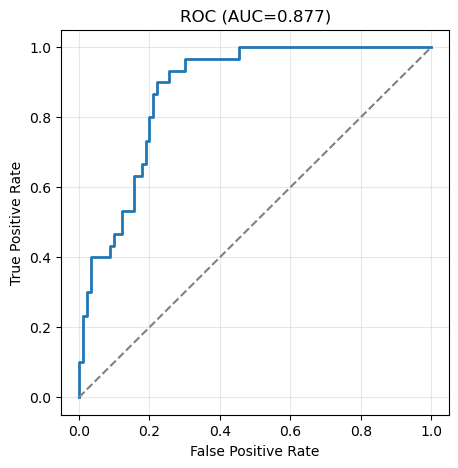

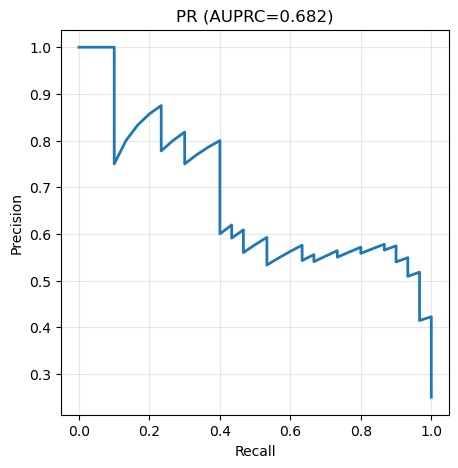

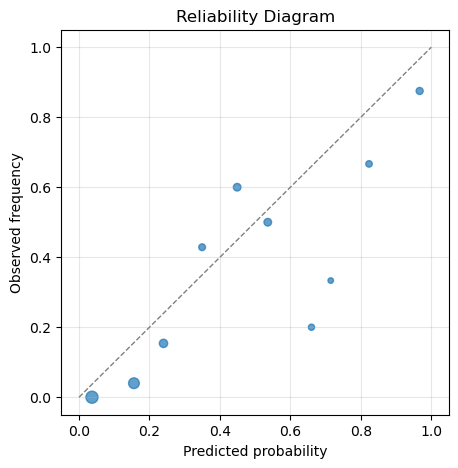

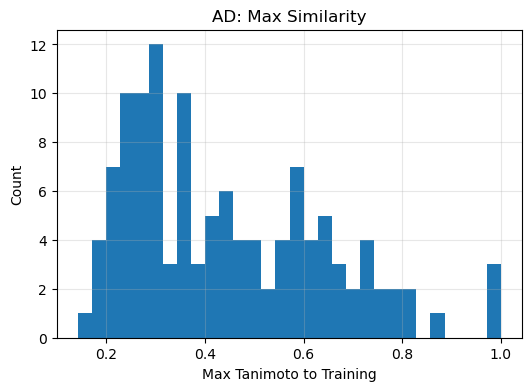

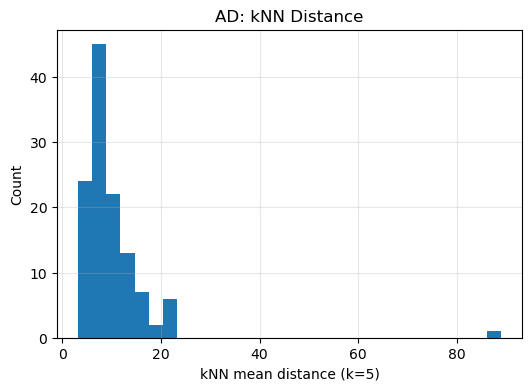

============================== Done! ==============================
Artifacts:
 - Predictions: data/exp_artifacts/exp0004_test_predictions_uncertainty_ad.csv
 - Summary: data/exp_artifacts/exp0004_metrics_summary.json


In [142]:
# basic ROC/PR with sklearn plotting (manual to avoid extra deps)
def plot_curves(y_true, y_prob, out_prefix: str):
    """Plot ROC and PR curves and save to files."""

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(5,5))
    plt.plot(fpr, tpr, lw=2)
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC (AUC={roc_auc_score(y_true,y_prob):.3f})"); plt.grid(alpha=0.3)
    plt.show()
    # plt.savefig(f"{out_prefix}_roc.png", bbox_inches="tight", dpi=160); plt.close()
    # PR
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(5,5))
    plt.plot(rec, prec, lw=2)
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"PR (AUPRC={average_precision_score(y_true,y_prob):.3f})"); plt.grid(alpha=0.3)
    # show figure in cell output
    plt.show()
    # plt.savefig(f"{out_prefix}_pr.png", bbox_inches="tight", dpi=160); plt.close()

plot_curves(y_test, p_test_mean, f"{OUTDIR}/exp0004")
plot_reliability(y_test, p_test_mean, bins=10, out_png=f"{OUTDIR}/exp0004_reliability.png")

# AD histograms
plt.figure(figsize=(6,4)); plt.hist(max_sim, bins=30); plt.xlabel("Max Tanimoto to Training"); plt.ylabel("Count"); plt.title("AD: Max Similarity"); plt.grid(alpha=0.3)
plt.show()
# plt.savefig(f"{OUTDIR}/exp0004_ad_maxsim.png", bbox_inches="tight", dpi=160); plt.close()
plt.figure(figsize=(6,4)); plt.hist(knn_dist, bins=30); plt.xlabel("kNN mean distance (k=5)"); plt.ylabel("Count"); plt.title("AD: kNN Distance"); plt.grid(alpha=0.3)
plt.show()
# plt.savefig(f"{OUTDIR}/exp0004_ad_knn.png", bbox_inches="tight", dpi=160); plt.close()

print("="*30, "Done!", "="*30)
print("Artifacts:")
print(" - Predictions:", preds_path)
print(" - Summary:", summary_path)
# print(" - ROC:", f"{OUTDIR}/exp0004_roc.png")
# print(" - PR:", f"{OUTDIR}/exp0004_pr.png")
# print(" - Reliability:", f"{OUTDIR}/exp0004_reliability.png")
# print(" - AD (maxsim):", f"{OUTDIR}/exp0004_ad_maxsim.png")
# print(" - AD (kNN):", f"{OUTDIR}/exp0004_ad_knn.png")

In [143]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

# Extract columns
prob_mean = preds["prob_mean"].values
prob_var  = preds["prob_var"].values
conformal_set = preds["conformal_set"].values
ad_flag = preds["ad_flag"].values

# -------------------------------
# 1. ROC Curve
# -------------------------------
fpr, tpr, _ = roc_curve(y_test, prob_mean)
auroc = roc_auc_score(y_test, prob_mean)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUROC = {auroc:.3f}', lw=2)
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(OUTDIR+"/roc_curve.png", dpi=160)
plt.close()

# -------------------------------
# 2. Precision-Recall Curve
# -------------------------------
prec, rec, _ = precision_recall_curve(y_test, prob_mean)
auprc = average_precision_score(y_test, prob_mean)

plt.figure(figsize=(6,6))
plt.plot(rec, prec, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUPRC = {auprc:.3f})")
plt.grid(alpha=0.3)
plt.savefig(OUTDIR+"/pr_curve.png", dpi=160)
plt.close()

# -------------------------------
# 3. Reliability Diagram
# -------------------------------
def ece(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    bins = np.linspace(0,1,n_bins+1); idx = np.digitize(y_prob, bins)-1
    ece_val = 0.0; N = len(y_true)
    for b in range(n_bins):
        m = idx==b
        if np.any(m):
            conf = y_prob[m].mean()
            acc  = y_true[m].mean()
            ece_val += (m.sum()/N) * abs(acc - conf)
    return ece_val

bins=10
bin_edges = np.linspace(0,1,bins+1)
inds = np.digitize(prob_mean, bin_edges)-1
accs, confs, sizes = [], [], []
for b in range(bins):
    m = inds==b
    if np.any(m):
        accs.append(y_test[m].mean())
        confs.append(prob_mean[m].mean())
        sizes.append(m.sum())
    else:
        accs.append(np.nan); confs.append((bin_edges[b]+bin_edges[b+1])/2); sizes.append(0)

plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1],'--', color='gray', lw=1)
plt.scatter(confs, accs, s=np.array(sizes)*2+10, alpha=0.7)
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title(f"Reliability Diagram (ECE={ece(y_test, prob_mean):.3f})")
plt.grid(alpha=0.3)
plt.savefig(OUTDIR+"/reliability_diagram.png", dpi=160)
plt.close()

# -------------------------------
# 4. Ensemble Variance Histogram
# -------------------------------
plt.figure(figsize=(6,4))
plt.hist(prob_var, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Ensemble Variance (prob_var)")
plt.ylabel("Count")
plt.title("Histogram of Ensemble Variance (Model Uncertainty)")
plt.grid(alpha=0.3)
plt.savefig(OUTDIR+"/ensemble_variance_hist.png", dpi=160)
plt.close()

# -------------------------------
# 5. Conformal Set Proportions
# -------------------------------
import collections
conformal_counts = collections.Counter(conformal_set)
plt.figure(figsize=(5,5))
plt.bar(conformal_counts.keys(), conformal_counts.values(), color='orange', edgecolor='black')
plt.xlabel("Conformal Set")
plt.ylabel("Count")
plt.title("Conformal Prediction Set Proportions")
plt.grid(axis='y', alpha=0.3)
plt.savefig(OUTDIR+"/conformal_set_proportions.png", dpi=160)
plt.close()

# -------------------------------
# 6. AD Flag Distributions
# -------------------------------
plt.figure(figsize=(6,4))
plt.hist(ad_flag, bins=3, color='red', edgecolor='black')
plt.xlabel("AD Flag (0=In-domain, 1=Out-of-domain)")
plt.ylabel("Count")
plt.title("Distribution of Applicability Domain (AD) Flags")
plt.grid(alpha=0.3)
plt.savefig(OUTDIR+"/ad_flag_distribution.png", dpi=160)
plt.close()

# Max Tanimoto and kNN distance distributions (optional)
if "max_tanimoto_to_train" in preds.columns:
    plt.figure(figsize=(6,4))
    plt.hist(preds["max_tanimoto_to_train"], bins=30, color='green', edgecolor='black')
    plt.xlabel("Max Tanimoto to Training")
    plt.ylabel("Count")
    plt.title("AD: Max Tanimoto Similarity")
    plt.grid(alpha=0.3)
    plt.savefig(OUTDIR+"/ad_max_tanimoto.png", dpi=160)
    plt.close()

if "knn_dist_5" in preds.columns:
    plt.figure(figsize=(6,4))
    plt.hist(preds["knn_dist_5"], bins=30, color='purple', edgecolor='black')
    plt.xlabel("kNN mean distance (k=5)")
    plt.ylabel("Count")
    plt.title("AD: kNN Distance")
    plt.grid(alpha=0.3)
    plt.savefig(OUTDIR+"/ad_knn_distance.png", dpi=160)
    plt.close()

# -------------------------------
# 7. Probability vs Variance Scatter
# -------------------------------
plt.figure(figsize=(6,5))
plt.scatter(prob_mean, prob_var, alpha=0.6, color='teal')
plt.xlabel("Predicted Probability (prob_mean)")
plt.ylabel("Ensemble Variance (prob_var)")
plt.title("Predicted Probability vs Ensemble Variance")
plt.grid(alpha=0.3)
plt.savefig(OUTDIR+"/prob_vs_variance_scatter.png", dpi=160)
plt.close()

# -------------------------------
# 8. Performance Stratified by AD
# -------------------------------
ad_in_mask = ad_flag==0
ad_out_mask = ad_flag==1

from sklearn.metrics import roc_auc_score, average_precision_score

auroc_in  = roc_auc_score(y_test[ad_in_mask], prob_mean[ad_in_mask])
auroc_out = roc_auc_score(y_test[ad_out_mask], prob_mean[ad_out_mask])

auprc_in  = average_precision_score(y_test[ad_in_mask], prob_mean[ad_in_mask])
auprc_out = average_precision_score(y_test[ad_out_mask], prob_mean[ad_out_mask])

plt.figure(figsize=(5,5))
plt.bar(["AD-in","AD-out"], [auroc_in, auroc_out], color=['blue','red'])
plt.ylabel("AUROC")
plt.title("Test AUROC Stratified by Applicability Domain")
plt.grid(axis='y', alpha=0.3)
plt.savefig(OUTDIR+"/auroc_ad_stratified.png", dpi=160)
plt.close()

plt.figure(figsize=(5,5))
plt.bar(["AD-in","AD-out"], [auprc_in, auprc_out], color=['blue','red'])
plt.ylabel("AUPRC")
plt.title("Test AUPRC Stratified by Applicability Domain")
plt.grid(axis='y', alpha=0.3)
plt.savefig(OUTDIR+"/auprc_ad_stratified.png", dpi=160)
plt.close()

print("All figures generated successfully.")
# -------------------------------

All figures generated successfully.


In [144]:
# ================================
# Extra Figures for Experiment 4
# ================================
X_train_raw = train_df[feature_cols].copy()
X_test_raw  = test_df[feature_cols].copy()
y_train = train_df["Label"].astype(int).values
y_test  = test_df["Label"].astype(int).values

# ============= 1) Class distribution (train + test) =============
def class_histogram(df, split_name, out_png):
    counts = df["Label"].value_counts().sort_index()
    plt.figure(figsize=(4,4))
    plt.bar(["neg (0)","pos (1)"], [counts.get(0,0), counts.get(1,0)])
    plt.title(f"Class Distribution — {split_name}")
    plt.ylabel("Count")
    plt.grid(axis="y", alpha=0.3)
    plt.savefig(out_png, dpi=160, bbox_inches="tight"); plt.close()

if not os.path.exists(OUTDIR):
    os.makedirs(OUTDIR)

class_histogram(train_df, "Train", os.path.join(OUTDIR, "class_distribution_train.png"))
class_histogram(test_df,  "Test",  os.path.join(OUTDIR, "class_distribution_test.png"))

# ============= 2) Correlation heatmaps (before & after) ============
def plot_corr_heatmap(df_num, title, out_png, max_features=60):
    # to avoid huge unreadable heatmaps, cap to first N features
    use_cols = df_num.columns[:max_features]
    C = np.corrcoef(df_num[use_cols].values.T)
    plt.figure(figsize=(6,5))
    im = plt.imshow(C, interpolation="none", aspect="auto")
    plt.title(title)
    plt.xticks(range(len(use_cols)), use_cols, rotation=90, fontsize=6)
    plt.yticks(range(len(use_cols)), use_cols, fontsize=6)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(out_png, dpi=160); plt.close()

# (a) BEFORE
plot_corr_heatmap(X_train_raw, "Feature Correlation (Before)", os.path.join(OUTDIR, "corr_heatmap_before.png"))

# Zero-variance removal
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train_raw)
keep_mask_vt = vt.get_support()
X_train_vt = X_train_raw.loc[:, keep_mask_vt]
X_test_vt  = X_test_raw.loc[:,  keep_mask_vt]
cols_vt = X_train_vt.columns.tolist()

# High-correlation removal (Pearson > 0.90)
def remove_high_corr(df, threshold=0.90):
    corr = df.corr().abs()
    upper = np.triu(np.ones(corr.shape), k=1).astype(bool)
    upper_corr = corr.where(upper)
    drop_cols = [col for col in upper_corr.columns if (upper_corr[col] > threshold).any()]
    keep_cols = [c for c in df.columns if c not in drop_cols]
    return df[keep_cols], keep_cols, drop_cols

X_train_clean, keep_cols_corr, dropped_corr = remove_high_corr(X_train_vt, threshold=0.90)
X_test_clean  = X_test_vt[keep_cols_corr].copy()

# (b) AFTER
plot_corr_heatmap(X_train_clean, "Feature Correlation (After VT + Corr>0.90 removal)",
                  os.path.join(OUTDIR, "corr_heatmap_after.png"))

# ============= 3.1) Top 20 features by GBC + BBC importance ===========
# Train a quick GBC + BBC on cleaned features (same split you already use)
# base_estimator = GBC(
#             n_estimators=int(params["n_estimators"]),
#             learning_rate=params["learning_rate"],
#             criterion=params["criterion"],
#             max_depth=int(params["max_depth"]),
#             max_features=params["max_features"],
#             subsample=params["subsample"],
#             random_state=42,
#             verbose=False
#         )

# models_gb = BalancedBaggingClassifier(
#     estimator=base_estimator,
#     n_estimators=10,
#     random_state=42,
#     n_jobs=-1
# )
# models_gb.fit(X_train_clean.values, y_train)

# ============= 4) Single bar chart: AUROC & AUPRC ================
# y_pred_eec = final_model_eec.predict_proba(X_test_processed)[:, 1]
# test_auroc_eec = roc_auc_score(y_test, y_pred_eec)
# test_auprc_eec = average_precision_score(y_test, y_pred_eec)
# test_brier_eec = brier_score_loss(y_test, y_pred_eec)

# Extract columns
prob_mean = preds["prob_mean"].values
prob_var  = preds["prob_var"].values
conformal_set = preds["conformal_set"].values
ad_flag = preds["ad_flag"].values

# -------------------------------
# 1. ROC Curve
# -------------------------------
auroc = roc_auc_score(y_test, prob_mean)
auprc = average_precision_score(y_test, prob_mean)

plt.figure(figsize=(4.5,4.5))
plt.bar(["AUROC","AUPRC"], [auroc, auprc])
for i, v in enumerate([auroc, auprc]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom")
plt.ylim(0, 1.05)
plt.title("Test Performance (Single Bar Chart)")
plt.grid(axis="y", alpha=0.3)
plt.savefig(os.path.join(OUTDIR, "auroc_auprc_barchart.png"), dpi=160, bbox_inches="tight"); plt.close()

# --------- Console summary ----------
print("Saved:")
print(" - class_distribution_train.png")
print(" - class_distribution_test.png")
print(" - corr_heatmap_before.png")
print(" - corr_heatmap_after.png")
# print(" - top_features_xgb.png")
print(" - auroc_auprc_barchart.png")
print(f"Features: before={len(feature_cols)}, after VT+Corr={X_train_clean.shape[1]} (dropped {len(feature_cols)-X_train_clean.shape[1]})")


e:\miniconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\miniconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Saved:
 - class_distribution_train.png
 - class_distribution_test.png
 - corr_heatmap_before.png
 - corr_heatmap_after.png
 - auroc_auprc_barchart.png
Features: before=196, after VT+Corr=140 (dropped 56)


In [148]:
js = "data/exp_artifacts-gb/exp0004_metrics_summary.json"
with open(js, "r") as f:
    summary = json.load(f)
summary["test_metrics"]

{'AUROC': 0.8737037037037036,
 'AUPRC': 0.7109917503448038,
 'Brier': 0.13033693497557416,
 'ECE': 0.1501209229909544}

In [149]:
# ==========================================
# Multi-model figures: BRF, EEC, XGB+BBC, GB+BBC, LGBM+BBC
# ==========================================
import os, json, glob, warnings

# --------------------------
# EDIT THIS SECTION ONLY
# --------------------------
OUTDIR = "data/exp_artifacts"  # where to save figures
MODELS = [
    {
        "name": "BRF",
        "summary": "data/exp_artifacts-brf/exp0004_metrics_summary.json",
        "preds":   "data/exp_artifacts-brf/exp0004_test_predictions_uncertainty_ad.csv",  # optional; required for reliability / conformal / AD plots
    },
    {
        "name": "EEC",
        "summary": "data/exp_artifacts-eec/exp0004_metrics_summary.json",
        "preds":   "data/exp_artifacts-eec/exp0004_test_predictions_uncertainty_ad.csv",
    },
    {
        "name": "XGB+BBC",
        "summary": "data/exp_artifacts-xgb/exp0004_metrics_summary.json",
        "preds":   "data/exp_artifacts-xgb/exp0004_test_predictions_uncertainty_ad.csv",
    },
    {
        "name": "GB+BBC",
        "summary": "data/exp_artifacts-gb/exp0004_metrics_summary.json",
        "preds":   "data/exp_artifacts-gb/exp0004_test_predictions_uncertainty_ad.csv",
    },
    {
        "name": "LGBM+BBC",
        "summary": "data/exp_artifacts-lgbm/exp0004_metrics_summary.json",
        "preds":   "data/exp_artifacts-lgbm/exp0004_test_predictions_uncertainty_ad.csv",
    },
    # Example using your sample:
    # {"name": "EXP-0004 (sample)", "summary": "/mnt/data/exp0004_metrics_summary.json",
    #  "preds": "/mnt/data/exp_0004_artifacts/exp0004_test_predictions_uncertainty_ad.csv"},
]
os.makedirs(OUTDIR, exist_ok=True)

# ---------------------------------
# Helpers
# ---------------------------------
def safe_read_json(p):
    try:
        with open(p, "r") as f:
            return json.load(f)
    except Exception as e:
        warnings.warn(f"Could not read JSON: {p} ({e})")
        return None

def ece_score(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    bins = np.linspace(0,1,n_bins+1); idx = np.digitize(y_prob, bins)-1
    ece = 0.0; N = len(y_true)
    for b in range(n_bins):
        m = idx==b
        if np.any(m):
            conf = y_prob[m].mean()
            acc  = y_true[m].mean()
            ece += (m.sum()/N) * abs(acc - conf)
    return float(ece)

def load_preds_csv(path):
    # expected columns: Label, prob_mean, prob_var, conformal_set, ad_flag, (optional) max_tanimoto_to_train, knn_dist_5
    try:
        df = pd.read_csv(path)
        return df
    except Exception as e:
        warnings.warn(f"Could not read preds CSV: {path} ({e})")
        return None

# Try to auto-guess a preds file near a summary if missing
def guess_preds_path(summary_path):
    cand_dir = os.path.dirname(summary_path)
    # look for any csv with 'pred' in name
    cands = glob.glob(os.path.join(cand_dir, "*.csv")) + glob.glob(os.path.join(cand_dir, "*/*pred**.csv"))
    for c in cands:
        name = os.path.basename(c).lower()
        if ("pred" in name or "test" in name) and name.endswith(".csv"):
            return c
    return None

# ---------------------------------
# 1) Collect metrics for bar chart
# ---------------------------------
perf_rows = []
models_data = []  # store everything for later plots
for m in MODELS:
    name = m["name"]
    summary = safe_read_json(m["summary"])
    print(summary)
    if summary is None:
        continue
    auroc = summary.get("test_metrics", {}).get("AUROC", None)
    auprc = summary.get("test_metrics", {}).get("AUPRC", None)
    brier = summary.get("test_metrics", {}).get("Brier", None)
    ece   = summary.get("test_metrics", {}).get("ECE", None)

    # prepare preds path if any
    preds_path = m.get("preds", None)
    if preds_path is None or not os.path.exists(preds_path):
        gp = guess_preds_path(m["summary"])
        if gp and os.path.exists(gp):
            preds_path = gp

    models_data.append({
        "name": name,
        "summary": m["summary"],
        "preds": preds_path,
        "auroc": auroc, "auprc": auprc, "brier": brier, "ece": ece
    })
    perf_rows.append({"Model": name, "AUROC": auroc, "AUPRC": auprc})

perf_df = pd.DataFrame(perf_rows).dropna(subset=["AUROC","AUPRC"])

# ---------------------------------
# Figure A: AUROC & AUPRC bar chart (one figure)
# ---------------------------------
if not perf_df.empty:
    plt.figure(figsize=(6,5))
    x = np.arange(len(perf_df))
    w = 0.35
    plt.bar(x - w/2, perf_df["AUROC"].values, width=w, label="AUROC")
    plt.bar(x + w/2, perf_df["AUPRC"].values, width=w, label="AUPRC")
    for i, v in enumerate(perf_df["AUROC"].values):
        plt.text(x[i]-w/2, v+0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    for i, v in enumerate(perf_df["AUPRC"].values):
        plt.text(x[i]+w/2, v+0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    plt.xticks(x, perf_df["Model"].values, rotation=15)
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title("AUROC & AUPRC across models")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "models_auroc_auprc_barchart.png"), dpi=160)
    plt.close()

# ---------------------------------
# 2) Reliability diagram per model (separate figure per model)
# ---------------------------------
def plot_reliability(y_true, y_prob, bins=10, title="", out_png=None):
    bin_edges = np.linspace(0,1,bins+1)
    inds = np.digitize(y_prob, bin_edges)-1
    accs, confs, sizes = [], [], []
    for b in range(bins):
        m = inds==b
        if np.any(m):
            accs.append(y_true[m].mean())
            confs.append(y_prob[m].mean())
            sizes.append(m.sum())
        else:
            accs.append(np.nan); confs.append( (bin_edges[b]+bin_edges[b+1])/2 ); sizes.append(0)
    plt.figure(figsize=(5,5))
    plt.plot([0,1],[0,1],'--', lw=1)
    plt.scatter(confs, accs, s=np.array(sizes)*2+10, alpha=0.7)
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(title)
    plt.grid(alpha=0.3)
    if out_png: plt.savefig(out_png, dpi=160, bbox_inches="tight")
    plt.close()

for md in models_data:
    if not md["preds"] or not os.path.exists(md["preds"]):
        warnings.warn(f"Skipping reliability for {md['name']}: no preds CSV.")
        continue
    dfp = load_preds_csv(md["preds"])
    if dfp is None or not {"Label","prob_mean"}.issubset(dfp.columns):
        warnings.warn(f"Skipping reliability for {md['name']}: required columns missing.")
        continue
    y = dfp["Label"].astype(int).values
    p = dfp["prob_mean"].values
    ece = ece_score(y, p, n_bins=10)
    plot_reliability(y, p, bins=10,
                     title=f"Reliability: {md['name']} (ECE={ece:.3f})",
                     out_png=os.path.join(OUTDIR, f"reliability_{md['name']}.png"))

# ---------------------------------
# 3) Conformal set proportions (combined)
# ---------------------------------
# expects column 'conformal_set' in preds CSVs
combo_counts = []
for md in models_data:
    if not md["preds"] or not os.path.exists(md["preds"]):
        continue
    dfp = load_preds_csv(md["preds"])
    if dfp is None or "conformal_set" not in dfp.columns:
        continue
    vc = dfp["conformal_set"].value_counts()
    row = {"Model": md["name"],
           "pos": int(vc.get("pos", 0)),
           "neg": int(vc.get("neg", 0)),
           "both": int(vc.get("both", 0)),
           "empty": int(vc.get("empty", 0))}
    combo_counts.append(row)

if combo_counts:
    conf_df = pd.DataFrame(combo_counts)
    conf_df = conf_df.set_index("Model")
    # stacked bars
    plt.figure(figsize=(7,5))
    bottom = np.zeros(len(conf_df))
    for col in ["pos","neg","both","empty"]:
        vals = conf_df[col].values
        plt.bar(conf_df.index, vals, bottom=bottom, label=col)
        bottom += vals
    plt.ylabel("Count")
    plt.title("Conformal prediction set proportions across models")
    plt.legend(title="Set")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "conformal_sets_across_models.png"), dpi=160)
    plt.close()

# ---------------------------------
# 4) Ensemble variance histogram per model (separate figures)
# ---------------------------------
for md in models_data:
    if not md["preds"] or not os.path.exists(md["preds"]):
        continue
    dfp = load_preds_csv(md["preds"])
    if dfp is None or "prob_var" not in dfp.columns:
        continue
    plt.figure(figsize=(6,4))
    plt.hist(dfp["prob_var"].values, bins=30, edgecolor="black")
    plt.xlabel("Ensemble variance (prob_var)")
    plt.ylabel("Count")
    plt.title(f"Uncertainty histogram — {md['name']}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"variance_hist_{md['name']}.png"), dpi=160)
    plt.close()

# ---------------------------------
# 5 & 6) AD-stratified AUROC and AUPRC (combined charts)
# ---------------------------------
rows_ad = []
for md in models_data:
    if not md["preds"] or not os.path.exists(md["preds"]):
        continue
    dfp = load_preds_csv(md["preds"])
    need = {"Label","prob_mean","ad_flag"}
    if dfp is None or not need.issubset(dfp.columns):
        continue
    y = dfp["Label"].astype(int).values
    p = dfp["prob_mean"].values
    ad = dfp["ad_flag"].astype(int).values
    mask_in = ad==0; mask_out = ad==1
    try:
        auroc_in  = roc_auc_score(y[mask_in], p[mask_in]) if mask_in.any() and (len(np.unique(y[mask_in]))>1) else np.nan
        auroc_out = roc_auc_score(y[mask_out], p[mask_out]) if mask_out.any() and (len(np.unique(y[mask_out]))>1) else np.nan
        auprc_in  = average_precision_score(y[mask_in], p[mask_in]) if mask_in.any() else np.nan
        auprc_out = average_precision_score(y[mask_out], p[mask_out]) if mask_out.any() else np.nan
    except Exception as e:
        warnings.warn(f"AD strat metrics failed for {md['name']}: {e}")
        auroc_in=auroc_out=auprc_in=auprc_out=np.nan
    rows_ad.append({"Model": md["name"],
                    "AUROC_in": auroc_in, "AUROC_out": auroc_out,
                    "AUPRC_in": auprc_in, "AUPRC_out": auprc_out})

if rows_ad:
    ad_df = pd.DataFrame(rows_ad).set_index("Model")

    # AUROC chart
    plt.figure(figsize=(7,5))
    x = np.arange(len(ad_df))
    w = 0.35
    plt.bar(x - w/2, ad_df["AUROC_in"].values, width=w, label="AD-in")
    plt.bar(x + w/2, ad_df["AUROC_out"].values, width=w, label="AD-out")
    plt.xticks(x, ad_df.index, rotation=15)
    plt.ylabel("AUROC")
    plt.title("AUROC stratified by applicability domain")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "auroc_ad_stratified_across_models.png"), dpi=160)
    plt.close()

    # AUPRC chart
    plt.figure(figsize=(7,5))
    plt.bar(x - w/2, ad_df["AUPRC_in"].values, width=w, label="AD-in")
    plt.bar(x + w/2, ad_df["AUPRC_out"].values, width=w, label="AD-out")
    plt.xticks(x, ad_df.index, rotation=15)
    plt.ylabel("AUPRC")
    plt.title("AUPRC stratified by applicability domain")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "auprc_ad_stratified_across_models.png"), dpi=160)
    plt.close()

print("Done. Figures saved to:", OUTDIR)


{'timestamp': '2025-09-11T09:28:17.400576', 'feature_cols': ['BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'ExactMolWt', 'FractionCSP3', 'HallKierAlpha', 'HeavyAtomCount', 'HeavyAtomMolWt', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'MaxAbsEStateIndex', 'MaxAbsPartialCharge', 'MaxEStateIndex', 'MaxPartialCharge', 'MinAbsEStateIndex', 'MinAbsPartialCharge', 'MinEStateIndex', 'MinPartialCharge', 'MolLogP', 'MolMR', 'MolWt', 'NHOHCount', 'NOCount', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAromaticRings', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRadicalElectrons', 'NumRotatableBonds', 'NumSaturatedCarbocycles', 'NumSaturatedHeterocycle

In [150]:
# Add numeric labels to bar charts and save updated figures
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Helper: robust bar labeling with fallback for older Matplotlib
def _label_bars(ax, bars, labels=None, fmt="%.3f", padding=3, center=False, fontsize=8, color=None):
    try:
        if hasattr(ax, "bar_label"):
            if labels is None:
                ax.bar_label(bars, fmt=fmt, padding=padding, fontsize=fontsize)
            else:
                # For stacked bars, use label_type="center" to place inside
                if center:
                    ax.bar_label(bars, labels=labels, label_type="center", fontsize=fontsize, color=(color or "white"))
                else:
                    ax.bar_label(bars, labels=labels, padding=padding, fontsize=fontsize, color=color)
            return
    except Exception:
        pass
    # Fallback manual placement
    for i, rect in enumerate(bars):
        h = rect.get_height()
        if np.isnan(h) or h == 0:
            continue
        x = rect.get_x() + rect.get_width()/2
        if center:
            y = rect.get_y() + h/2
            txt = labels[i] if labels is not None else (fmt % h)
            ax.text(x, y, txt, ha="center", va="center", fontsize=fontsize, color=(color or "white"))
        else:
            y = rect.get_y() + h + 0.01 * (ax.get_ylim()[1] - ax.get_ylim()[0])
            txt = labels[i] if labels is not None else (fmt % h)
            ax.text(x, y, txt, ha="center", va="bottom", fontsize=fontsize, color=color)

# Resolve output directory
_outdir = None
try:
    _outdir = OUTDIR  # defined earlier in the notebook
except NameError:
    try:
        _outdir = os.path.join(DRIVE_ROOT, "exp_artifacts")
    except NameError:
        _outdir = os.getcwd()
os.makedirs(_outdir, exist_ok=True)

# 1) AUROC & AUPRC across models (grouped bars)
if "perf_df" in globals() and isinstance(perf_df, pd.DataFrame) and not perf_df.empty:
    need = {"Model", "AUROC", "AUPRC"}
    if need.issubset(perf_df.columns):
        df = perf_df.dropna(subset=["AUROC", "AUPRC"]).copy()
        if not df.empty:
            fig, ax = plt.subplots(figsize=(6, 5))
            x = np.arange(len(df))
            w = 0.35
            bars1 = ax.bar(x - w/2, df["AUROC"].values, width=w, label="AUROC")
            bars2 = ax.bar(x + w/2, df["AUPRC"].values, width=w, label="AUPRC")
            _label_bars(ax, bars1, fmt="%.3f", padding=3)
            _label_bars(ax, bars2, fmt="%.3f", padding=3)
            ax.set_xticks(x)
            ax.set_xticklabels(df["Model"].values, rotation=15)
            ax.set_ylim(0, 1.05)
            ax.set_ylabel("Score")
            ax.set_title("AUROC & AUPRC across models")
            ax.legend()
            ax.grid(axis="y", alpha=0.3)
            fig.tight_layout()
            fig.savefig(os.path.join(_outdir, "models_auroc_auprc_barchart.png"), dpi=160)
            plt.close(fig)

# 2) Conformal set proportions across models (stacked bars)
if "conf_df" in globals() and isinstance(conf_df, pd.DataFrame) and not conf_df.empty:
    cols = [c for c in ["pos", "neg", "both", "empty"] if c in conf_df.columns]
    if cols:
        fig, ax = plt.subplots(figsize=(7, 5))
        index = np.arange(len(conf_df))
        bottom = np.zeros(len(conf_df))
        colors = {"pos": "#2ca02c", "neg": "#d62728", "both": "#1f77b4", "empty": "#7f7f7f"}
        for c in cols:
            vals = conf_df[c].values
            bars = ax.bar(conf_df.index, vals, bottom=bottom, label=c, color=colors.get(c, None))
            # Center labels for stacked bars; hide zeros
            labels = [f"{int(v)}" if v and v > 0 else "" for v in vals]
            _label_bars(ax, bars, labels=labels, center=True)
            bottom += vals
        ax.set_ylabel("Count")
        ax.set_title("Conformal prediction set proportions across models")
        ax.legend(title="Set")
        ax.grid(axis="y", alpha=0.3)
        fig.tight_layout()
        fig.savefig(os.path.join(_outdir, "conformal_sets_across_models.png"), dpi=160)
        plt.close(fig)

# 3) AUROC stratified by AD (grouped bars)
if "ad_df" in globals() and isinstance(ad_df, pd.DataFrame) and not ad_df.empty:
    # Ensure expected columns exist
    if {"AUROC_in", "AUROC_out"}.issubset(ad_df.columns):
        fig, ax = plt.subplots(figsize=(7, 5))
        x = np.arange(len(ad_df)); w = 0.35
        bars_in = ax.bar(x - w/2, ad_df["AUROC_in"].values, width=w, label="AD-in")
        bars_out = ax.bar(x + w/2, ad_df["AUROC_out"].values, width=w, label="AD-out")
        _label_bars(ax, bars_in, fmt="%.3f", padding=3)
        _label_bars(ax, bars_out, fmt="%.3f", padding=3)
        ax.set_xticks(x)
        ax.set_xticklabels(ad_df.index, rotation=15)
        ax.set_ylabel("AUROC")
        ax.set_title("AUROC stratified by applicability domain")
        ax.legend()
        ax.grid(axis="y", alpha=0.3)
        fig.tight_layout()
        fig.savefig(os.path.join(_outdir, "auroc_ad_stratified_across_models.png"), dpi=160)
        plt.close(fig)

    # 4) AUPRC stratified by AD (grouped bars)
    if {"AUPRC_in", "AUPRC_out"}.issubset(ad_df.columns):
        fig, ax = plt.subplots(figsize=(7, 5))
        x = np.arange(len(ad_df)); w = 0.35
        bars_in = ax.bar(x - w/2, ad_df["AUPRC_in"].values, width=w, label="AD-in")
        bars_out = ax.bar(x + w/2, ad_df["AUPRC_out"].values, width=w, label="AD-out")
        _label_bars(ax, bars_in, fmt="%.3f", padding=3)
        _label_bars(ax, bars_out, fmt="%.3f", padding=3)
        ax.set_xticks(x)
        ax.set_xticklabels(ad_df.index, rotation=15)
        ax.set_ylabel("AUPRC")
        ax.set_title("AUPRC stratified by applicability domain")
        ax.legend()
        ax.grid(axis="y", alpha=0.3)
        fig.tight_layout()
        fig.savefig(os.path.join(_outdir, "auprc_ad_stratified_across_models.png"), dpi=160)
        plt.close(fig)

print(f"Bar labels added. Figures saved to: {_outdir}")

Bar labels added. Figures saved to: data/exp_artifacts


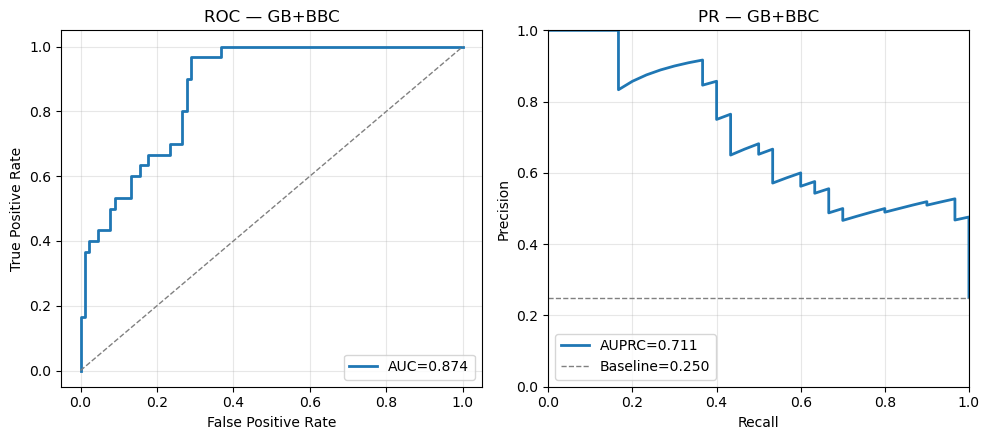

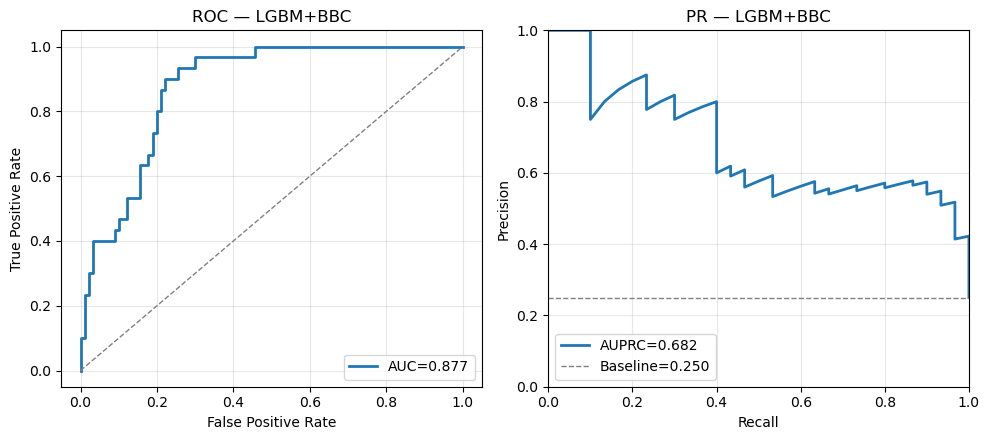

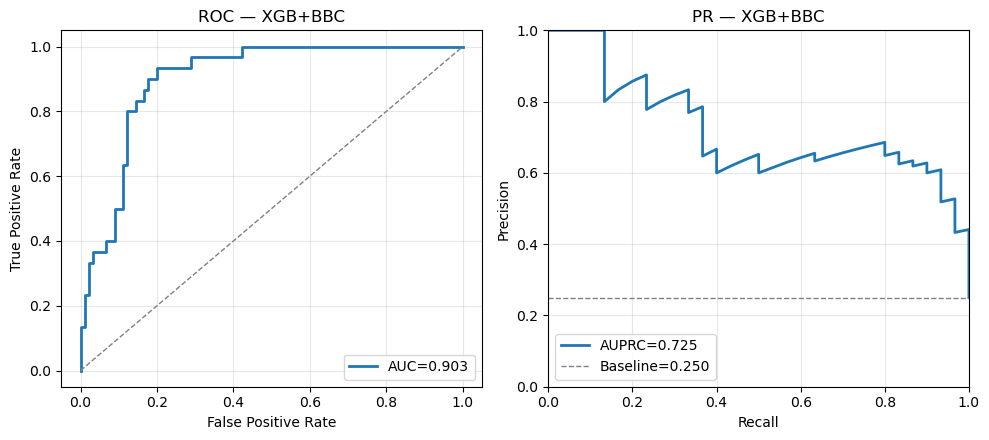

Saved combined ROC+PR figures to: data/exp_artifacts


In [151]:
# Combined ROC+PR figures per model
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score


def plot_roc_pr_combined(y_true, y_prob, model_name: str, out_path: str = None, show: bool = True, save: bool = True):
    """Create a single figure with ROC and PR subplots for a model."""
    # Metrics
    auc = float(roc_auc_score(y_true, y_prob))
    ap  = float(average_precision_score(y_true, y_prob))
    pos_rate = float(np.mean(y_true))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

    # ROC subplot
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax = axes[0]
    ax.plot(fpr, tpr, lw=2, label=f"AUC={auc:.3f}")
    ax.plot([0, 1], [0, 1], '--', color='gray', lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC — {model_name}")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

    # PR subplot
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ax = axes[1]
    ax.plot(rec, prec, lw=2, label=f"AUPRC={ap:.3f}")
    ax.hlines(pos_rate, 0, 1, colors='gray', linestyles='--', lw=1, label=f"Baseline={pos_rate:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"PR — {model_name}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="lower left")
    ax.grid(alpha=0.3)

    fig.tight_layout()
    if save and out_path:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        fig.savefig(out_path, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

# Build list of available models from variables present in the notebook
models_for_curves = []
if 'p_test_mean_gb' in globals():
    models_for_curves.append(("GB+BBC", p_test_mean_gb))
if 'p_test_mean_lgb' in globals():
    models_for_curves.append(("LGBM+BBC", p_test_mean_lgb))
if 'p_test_mean_xgb' in globals():
    models_for_curves.append(("XGB+BBC", p_test_mean_xgb))

# Determine output directory
try:
    outdir = OUTDIR
except NameError:
    try:
        outdir = os.path.join(DRIVE_ROOT, 'exp_artifacts')
    except NameError:
        outdir = os.getcwd()

# Generate combined figures per model
if 'y_test' in globals() and len(models_for_curves) > 0:
    for model_name, y_prob in models_for_curves:
        safe_name = model_name.lower().replace('+','').replace(' ','_')
        out_path = os.path.join(outdir, f"roc_pr_{safe_name}.png")
        plot_roc_pr_combined(y_test, y_prob, model_name, out_path=out_path, show=True, save=True)
    print(f"Saved combined ROC+PR figures to: {outdir}")
else:
    print("No models available or y_test missing. Skipping combined ROC+PR generation.")

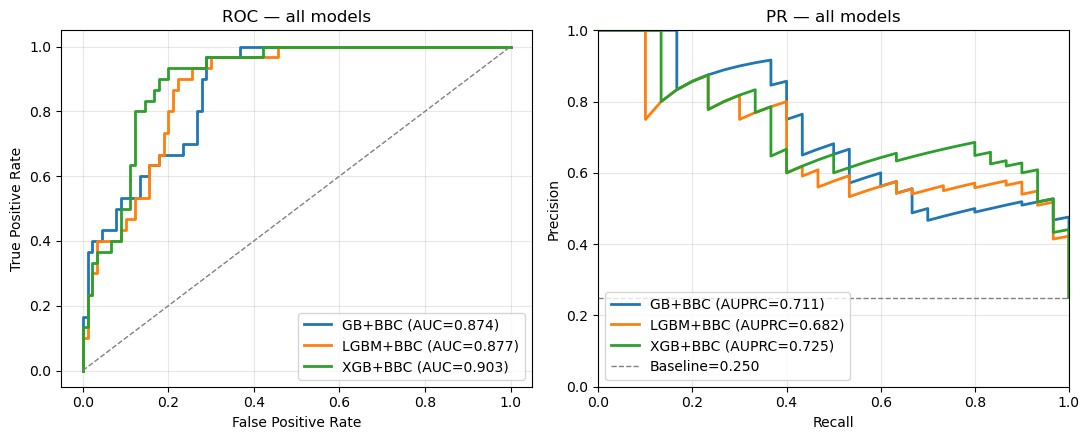

Saved: data/exp_artifacts\roc_pr_all_models.png


In [152]:
# One figure with all models: ROC (left) and PR (right)
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

# Collect available model outputs
all_models = []
if 'p_test_mean_gb' in globals():
    all_models.append(("GB+BBC", p_test_mean_gb))
if 'p_test_mean_lgb' in globals():
    all_models.append(("LGBM+BBC", p_test_mean_lgb))
if 'p_test_mean_xgb' in globals():
    all_models.append(("XGB+BBC", p_test_mean_xgb))

if 'y_test' in globals() and len(all_models) > 0:
    # Colors cycle
    cmap = plt.get_cmap('tab10')

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # ROC subplot
    ax = axes[0]
    for i, (label, probs) in enumerate(all_models):
        fpr, tpr, _ = roc_curve(y_test, probs)
        auc = roc_auc_score(y_test, probs)
        ax.plot(fpr, tpr, lw=2, color=cmap(i), label=f"{label} (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], '--', color='gray', lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC — all models")
    ax.grid(alpha=0.3)
    ax.legend(loc='lower right')

    # PR subplot
    ax = axes[1]
    pos_rate = float(np.mean(y_test))
    for i, (label, probs) in enumerate(all_models):
        prec, rec, _ = precision_recall_curve(y_test, probs)
        ap = average_precision_score(y_test, probs)
        ax.plot(rec, prec, lw=2, color=cmap(i), label=f"{label} (AUPRC={ap:.3f})")
    ax.hlines(pos_rate, 0, 1, colors='gray', linestyles='--', lw=1, label=f"Baseline={pos_rate:.3f}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("PR — all models")
    ax.grid(alpha=0.3)
    ax.legend(loc='lower left')

    fig.tight_layout()
    # Save
    try:
        outdir = OUTDIR
    except NameError:
        try:
            outdir = os.path.join(DRIVE_ROOT, 'exp_artifacts')
        except NameError:
            outdir = os.getcwd()
    os.makedirs(outdir, exist_ok=True)
    out_path = os.path.join(outdir, 'roc_pr_all_models.png')
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f"Saved: {out_path}")
else:
    print("Missing y_test or no model probabilities found.")

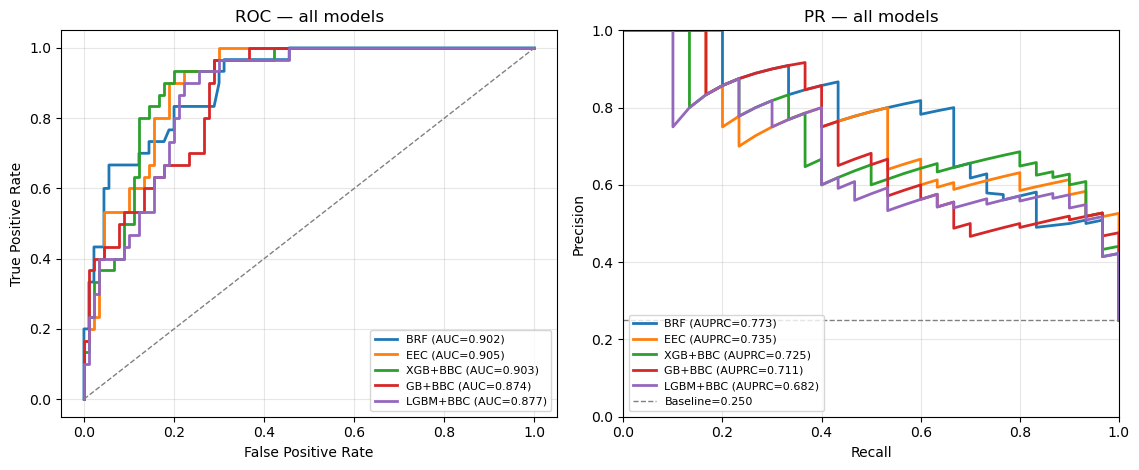

Saved combined figure: data\exp_common_artifacts\roc_pr_all_models.png


In [ ]:
# All models in one figure (ROC + PR), reading from MODELS[*]["preds"] CSVs
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

# Resolve paths robustly for Windows/relative notebooks
def resolve_path(p: str):
    if p is None:
        return None
    if os.path.isabs(p):
        return p
    if os.path.exists(p):
        return p
    p_norm = p.replace('\\', '/').lstrip('./')
    # If DRIVE_ROOT points to base data dir, allow "data/..." mapping
    if 'DRIVE_ROOT' in globals():
        if p_norm.startswith('data/'):
            alt = os.path.join(DRIVE_ROOT, p_norm[len('data/'):])
            if os.path.exists(alt):
                return alt
        alt2 = os.path.join(DRIVE_ROOT, p_norm)
        if os.path.exists(alt2):
            return alt2
    return p  # fallback; may still work if CWD later changes

# Try to infer the probability and label columns
PROB_COL_CANDIDATES = ["prob_mean", "y_prob", "prob", "proba", "p", "prediction", "score"]
LABEL_COL_CANDIDATES = ["Label", "label", "y_true", "target", "y"]

def get_cols(df: pd.DataFrame):
    prob_col = next((c for c in PROB_COL_CANDIDATES if c in df.columns), None)
    label_col = next((c for c in LABEL_COL_CANDIDATES if c in df.columns), None)
    return prob_col, label_col

# Output directory preference: common multi-model folder under data
def get_outdir():
    # Prefer a shared folder if DRIVE_ROOT exists
    if 'DRIVE_ROOT' in globals():
        out = os.path.join(DRIVE_ROOT, 'exp_common_artifacts')
        os.makedirs(out, exist_ok=True)
        return out
    # Else fallback to OUTDIR or CWD
    try:
        out = OUTDIR
        os.makedirs(out, exist_ok=True)
        return out
    except NameError:
        out = os.path.join(os.getcwd(), 'exp_common_artifacts')
        os.makedirs(out, exist_ok=True)
        return out

# Collect data from MODELS
curves = []  # list of dict(name, y, p)
if 'MODELS' in globals():
    for m in MODELS:
        name = m.get('name', 'model')
        preds_path = resolve_path(m.get('preds'))
        if preds_path is None or not os.path.exists(preds_path):
            print(f"Skip {name}: preds CSV not found -> {preds_path}")
            continue
        try:
            dfp = pd.read_csv(preds_path)
        except Exception as e:
            print(f"Skip {name}: failed to read CSV ({e})")
            continue
        prob_col, label_col = get_cols(dfp)
        if not prob_col or not label_col:
            print(f"Skip {name}: missing required columns (found: {list(dfp.columns)[:6]}...)")
            continue
        y = dfp[label_col].astype(int).values
        p = dfp[prob_col].astype(float).values
        # Guard against degenerate curves (all same label)
        if len(np.unique(y)) < 2:
            print(f"Skip {name}: only one class present in y")
            continue
        curves.append({"name": name, "y": y, "p": p})
else:
    print("MODELS variable not found. Define MODELS with 'name' and 'preds' entries.")

# Plot if we have at least one model
if len(curves) > 0:
    outdir = get_outdir()
    cmap = plt.get_cmap('tab10')

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

    # ROC
    ax = axes[0]
    for i, it in enumerate(curves):
        fpr, tpr, _ = roc_curve(it['y'], it['p'])
        auc = roc_auc_score(it['y'], it['p'])
        ax.plot(fpr, tpr, lw=2, color=cmap(i % 10), label=f"{it['name']} (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], '--', color='gray', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC — ')
    ax.grid(alpha=0.3)
    ax.legend(loc='lower right', fontsize=8)

    # PR
    ax = axes[1]
    # Use baseline from the first model's labels
    pos_rate = float(np.mean(curves[0]['y']))
    for i, it in enumerate(curves):
        prec, rec, _ = precision_recall_curve(it['y'], it['p'])
        ap = average_precision_score(it['y'], it['p'])
        ax.plot(rec, prec, lw=2, color=cmap(i % 10), label=f"{it['name']} (AUPRC={ap:.3f})")
    ax.hlines(pos_rate, 0, 1, colors='gray', linestyles='--', lw=1, label=f"Baseline={pos_rate:.3f}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('PR — ')
    ax.grid(alpha=0.3)
    ax.legend(loc='lower left', fontsize=8)

    fig.tight_layout()
    out_path = os.path.join(outdir, 'roc_pr_all_models.png')
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f"Saved combined figure: {out_path}")
else:
    print("No valid model predictions found from MODELS; nothing to plot.")

In [155]:
# Per-model classification metrics: Accuracy, Sensitivity, Specificity, MCC, AUROC, AUPRC
import os
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score

# --- Config: choose thresholding strategy ---
# 'fixed' -> use FIXED_THRESHOLD; 'youden' -> pick threshold maximizing (TPR - FPR)
THRESH_STRATEGY = 'fixed'  # 'fixed' or 'youden'
FIXED_THRESHOLD = 0.5

# Reuse helpers if defined earlier; otherwise define light versions
try:
    resolve_path
except NameError:
    def resolve_path(p: str):
        if p is None:
            return None
        if os.path.isabs(p) or os.path.exists(p):
            return p
        p_norm = p.replace('\\', '/').lstrip('./')
        if 'DRIVE_ROOT' in globals():
            if p_norm.startswith('data/'):
                alt = os.path.join(DRIVE_ROOT, p_norm[len('data/'):])
                if os.path.exists(alt):
                    return alt
            alt2 = os.path.join(DRIVE_ROOT, p_norm)
            if os.path.exists(alt2):
                return alt2
        return p

try:
    get_cols
except NameError:
    PROB_COL_CANDIDATES = ["prob_mean", "y_prob", "prob", "proba", "p", "prediction", "score"]
    LABEL_COL_CANDIDATES = ["Label", "label", "y_true", "target", "y"]
    def get_cols(df: pd.DataFrame):
        prob_col = next((c for c in PROB_COL_CANDIDATES if c in df.columns), None)
        label_col = next((c for c in LABEL_COL_CANDIDATES if c in df.columns), None)
        return prob_col, label_col

# Output folder
def _out_dir():
    if 'DRIVE_ROOT' in globals():
        d = os.path.join(DRIVE_ROOT, 'exp_common_artifacts')
        os.makedirs(d, exist_ok=True)
        return d
    try:
        d = OUTDIR
        os.makedirs(d, exist_ok=True)
        return d
    except NameError:
        d = os.path.join(os.getcwd(), 'exp_common_artifacts')
        os.makedirs(d, exist_ok=True)
        return d

# Compute metrics at a given threshold
from math import sqrt

def compute_metrics_at(y_true: np.ndarray, y_prob: np.ndarray, thr: float):
    y_pred = (y_prob >= thr).astype(int)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    n = tp + tn + fp + fn
    acc = (tp + tn) / n if n else np.nan
    sens = tp / (tp + fn) if (tp + fn) else np.nan  # recall
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    prec = tp / (tp + fp) if (tp + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan
    bal_acc = (sens + spec) / 2 if (not np.isnan(sens) and not np.isnan(spec)) else np.nan
    f1 = (2 * prec * sens) / (prec + sens) if (prec is not np.nan and sens is not np.nan and (prec + sens)) else np.nan
    denom = sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = ((tp * tn) - (fp * fn)) / denom if denom else np.nan
    return {
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'N': n, 'Threshold': thr,
        'Accuracy': acc,
        'Sensitivity': sens,
        'Specificity': spec,
        'Precision': prec,
        'NPV': npv,
        'Balanced_Accuracy': bal_acc,
        'F1': f1,
        'MCC': mcc,
        'Prevalence': float(np.mean(y_true))
    }

# Determine threshold via strategy
def pick_threshold(y_true: np.ndarray, y_prob: np.ndarray, strategy: str):
    if strategy == 'fixed':
        return float(FIXED_THRESHOLD)
    if strategy == 'youden':
        fpr, tpr, thr = roc_curve(y_true, y_prob)
        j = tpr - fpr
        idx = int(np.nanargmax(j))
        return float(thr[idx])
    return float(FIXED_THRESHOLD)

# Run over MODELS
rows = []
if 'MODELS' in globals():
    for m in MODELS:
        name = m.get('name', 'model')
        preds_path = resolve_path(m.get('preds'))
        if preds_path is None or not os.path.exists(preds_path):
            print(f"Skip {name}: preds CSV not found -> {preds_path}")
            continue
        try:
            dfp = pd.read_csv(preds_path)
        except Exception as e:
            print(f"Skip {name}: failed to read CSV ({e})")
            continue
        prob_col, label_col = get_cols(dfp)
        if not prob_col or not label_col:
            print(f"Skip {name}: missing required columns. Present: {list(dfp.columns)[:8]}...")
            continue
        y = dfp[label_col].astype(int).values
        p = dfp[prob_col].astype(float).values
        if len(np.unique(y)) < 2:
            print(f"Skip {name}: only one class present in labels")
            continue
        # Threshold-based metrics
        thr = pick_threshold(y, p, THRESH_STRATEGY)
        metrics = compute_metrics_at(y, p, thr)
        # Threshold-free metrics
        metrics['AUROC'] = float(roc_auc_score(y, p))
        metrics['AUPRC'] = float(average_precision_score(y, p))
        metrics.update({'Model': name})
        rows.append(metrics)
else:
    print("MODELS not defined. Define it with 'name' and 'preds' entries.")

if rows:
    metrics_df = pd.DataFrame(rows).set_index('Model')
    display(metrics_df[[
        'Threshold', 'N', 'Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'NPV', 'Balanced_Accuracy', 'F1', 'MCC', 'AUROC', 'AUPRC', 'Prevalence'
    ]].round(4))
    out_csv = os.path.join(_out_dir(), 'classification_metrics_summary.csv')
    metrics_df.to_csv(out_csv)
    print(f"Saved metrics summary to: {out_csv}")
else:
    print("No metrics computed. Check MODELS paths and CSV columns (need probability and label columns).")

,Threshold,N,Accuracy,Sensitivity,Specificity,Precision,NPV,Balanced_Accuracy,F1,MCC,AUROC,AUPRC,Prevalence
Model,,,,,,,,,,,,,
BRF,0.5,120,0.8000,0.2333,0.9889,0.8750,0.7946,0.6111,0.3684,0.3858,0.9017,0.7728,0.25
EEC,0.5,120,0.8250,0.9000,0.8000,0.6000,0.9600,0.8500,0.7200,0.6261,0.9048,0.7354,0.25
XGB+BBC,0.5,120,0.8417,0.9000,0.8222,0.6279,0.9610,0.8611,0.7397,0.6522,0.9026,0.7254,0.25
GB+BBC,0.5,120,0.8000,0.6000,0.8667,0.6000,0.8667,0.7333,0.6000,0.4667,0.8737,0.7110,0.25
LGBM+BBC,0.5,120,0.7833,0.6000,0.8444,0.5625,0.8636,0.7222,0.5806,0.4352,0.8767,0.6816,0.25


Saved metrics summary to: data\exp_common_artifacts\classification_metrics_summary.csv
